In [2]:
#Functions for CSV Processing
from bdb import effective
import os
from pathlib import Path
from site import check_enableusersite
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from astropy.io import fits
import math
from matplotlib.lines import Line2D
from collections import Counter
from reproject import reproject_exact, reproject_adaptive, reproject_interp
# Force output display
from IPython.display import display
import sys

sys.stdout.flush()  # Force flush

# Also check if you have this at the top of your notebook
# %config InteractiveShell.ast_node_interactivity='all'

#Modify for IC5146 and other scales
scale_colors = {
    "16": "red",
    "32": "orange",
    "64": "lightblue",
    "128": "darkblue",
    "256": "purple"
}



def getInfo(label, csv_path):

    """
    Read the csv file for information about an image and return the distance, res, pixscale, and powers of 2

    Parameter
    - label (str): The label for the celestial object that the image is of, commonly a galaxy name
    - csv_path (str): The path to the csv file containing relevant information

    Returns:
    - distance (float): distance to the image
    - res (float): angular resolution
    - pixscale (float): pixel resolution
    - min_power (float): minimum power of 2 for scale decomposition
    - max_power (float): maximum power of 2 for scale decomposition

    """

    table = pd.read_excel(csv_path)
    label, band = label.split("_")

    try: 
        label_info = table[
            (table['label'].str.lower() == label.lower()) & 
            (table['Band'].str.lower() == band.lower())
        ]
    except KeyError as e:
        print("Error: Cannot find 'label' in csv file")
        exit(1)

    if not label_info.empty:
        distance = label_info.iloc[0]['current_dist']
        res = label_info.iloc[0]['res']
        pixscale = label_info.iloc[0]['pixscale']
        min_power = label_info.iloc[0]['Power of 2 min']
        max_power = label_info.iloc[0]['Power of 2 max']
        Rem_sources = label_info.iloc[0]['Rem_sources']
        Band = label_info.iloc[0]['Band']
        Instr = label_info.iloc[0]['INSTR']

        MJysr = np.nan #not needed

        return distance, res, pixscale, MJysr, Band, min_power, max_power, bool(Rem_sources)
    
    else: 
        print("Image not found in csv!")
        
def getScale(file):
    scales = ["256", "128", "64", "32", "16"]
    for scale in scales:
        if f"{scale}" in file:
            return scale
    return None

def get_min_scale(synthetic_folder):
    min_scale = float('inf')
    for file in os.listdir(synthetic_folder):
        if file.endswith(".fits"):
            file_path = os.path.join(synthetic_folder, file)
            scale = getScale(file_path)
            if scale is not None and float(scale) < min_scale:
                min_scale = float(scale)
    return min_scale if min_scale != float('inf') else None

def plot_quantity(data_dict, quantity_type, ax, region = -1):
    
    
    region_dict = {
    1: "center",
    2: "bar",
    3: "bar",
    4: "interarm",
    5: "spiral",
    6: "spiral",
    7: "interarm",
    8: "interarm",
    9: "disc",
    10: "disc"
    }
    num_fils = 0
    for scale in sorted(data_dict.keys(), key=lambda x: float(x)):
        data = np.array(data_dict[scale])
        num_fils += len(data)
        # Skip if no data
        if len(data) == 0:
            print(f"Warning: No data for {quantity_type} at scale {scale}")
            continue
            
        if quantity_type == "curvature":
            plot_data = data
        else:
            plot_data = np.log10(data[data > 0])
            
        color = scale_colors.get(scale, None)
        if len(plot_data) > 0:  # Only plot if we have data
            sns.kdeplot(plot_data, label=f"{scale} pc", linewidth=2, color=color, ax=ax)

    # Set x-axis labels and limits
    ax.set_xlabel({
        "length": "log(pc)",
        "mass": "log(M)",
        "density": "log(M/pc)",
        "curvature": "Radians",
        "surface_density": "log(M/pc^2)"
    }[quantity_type])
    
    ax.set_ylabel("Density")
    if region != -1:
        region_label = region_dict.get(int(region))
        ax.set_title(f'{quantity_type.capitalize()} for region {region_label} ({int(region)}),\n {num_fils} total filaments')

    else:
        ax.set_title(quantity_type.capitalize())
    ax.grid(True, which="both", ls="--")

    # Set appropriate x-axis limits
    xlims = {
        "length": (1, 5),
        "mass": (2, 8),
        "density": (0, 5),
        "curvature": (0, 2),  
        "surface_density": (-4,4.5) 
        }
    if quantity_type in xlims:
        ax.set_xlim(xlims[quantity_type])




def plot_galaxy_image(fits_folder, galaxy_name, ax):
    try:
        for file in os.listdir(fits_folder):
            if file.endswith(".fits") and galaxy_name.lower() in file.lower():
                fits_path = os.path.join(fits_folder, file)
                with fits.open(fits_path) as hdul:
                    image_data = hdul[0].data
                    if image_data is not None:
                        image = np.nan_to_num(image_data)

                        # Pad image to square
                        y, x = image.shape
                        size = max(x, y)
                        pad_x = (size - x) // 2
                        pad_y = (size - y) // 2
                        image = np.pad(image, ((pad_y, size - y - pad_y), (pad_x, size - x - pad_x)), 
                                       mode='constant', constant_values=0)

                        vmin, vmax = (0,20) #Plot all galaxies with same scale
                        ax.imshow(image, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
                        ax.set_title(galaxy_name, fontsize=12)
                        ax.axis('off')
                        return
        ax.set_title(f"{galaxy_name} (Image Not Found)", fontsize=10)
        ax.axis('off')
    except Exception:
        ax.set_title(f"{galaxy_name} (Error)", fontsize=10)
        ax.axis('off')

def get_rows(galaxy_subset, galaxy_data):
    region_sum = 0
    for i, galaxy in enumerate(galaxy_subset):
        data = galaxy_data[galaxy]
        region_data = data['region']
        region_data_combined = []
        region_counts = []
        valid_regions = []
        for scale in sorted(region_data.keys(), key=lambda x: float(x)):
            region_data_combined.append(region_data[scale])
        region_data_combined = np.concatenate(region_data_combined)
        vals, freqs = np.unique(region_data_combined, return_counts=True)
        region_counts = dict(zip(vals, freqs))
        valid_regions = [r for r, cnt in region_counts.items() if cnt >= 10]
        region_sum += len(valid_regions)
    return region_sum

def plot_galaxies_subset(galaxy_subset, filename, fits_folder, galaxy_data, output_folder, sort_region=False, Write=True):
    num = len(galaxy_subset)
    
    # Calculate total rows first
    if sort_region:
        total_rows = sum(get_rows([galaxy], galaxy_data) for galaxy in galaxy_subset)
    else:
        total_rows = num
    
    # Create figure with extra height for legend
    extra_legend_height = 0.8  # Additional inches for legend space
    fig = plt.figure(figsize=(25, 4.8 * total_rows + extra_legend_height))
    
    # Create gridspec with a dedicated row for the legend
    if sort_region:
        gs = gridspec.GridSpec(total_rows + 1, 6, figure=fig, height_ratios=[0.3] + [1] * total_rows)
    else:
        gs = gridspec.GridSpec(total_rows + 1, 6, figure=fig, height_ratios=[0.3] + [1] * total_rows)

    # Create legend in the top row (row 0)
    legend_elements = [
        Line2D([0], [0], color=color, lw=3)
        for scale, color in sorted(scale_colors.items(), key=lambda x: float(x[0]))
    ]
    
    legend_ax = fig.add_subplot(gs[0, :])
    legend_ax.axis('off')
    legend_ax.legend(
        handles=legend_elements,
        labels=[f"{scale} pc" for scale in sorted(scale_colors, key=float)],
        loc='center',
        ncol=len(scale_colors),
        fontsize=14,  # Slightly larger for visibility
        frameon=False
    )

    # Now plot your data starting from row 1
    start = 1  # Start from row 1 instead of 0
    for i, galaxy in enumerate(galaxy_subset):
        data = galaxy_data[galaxy]

        if sort_region:
            modified_mass_dict = {}
            modified_length_dict = {}
            modified_density_dict = {}
            modified_surface_density_dict = {}
            modified_curvature_dict = {}

            # ... your region processing code ...
            data = galaxy_data[galaxy]
            region_data_all = data['region']

            for scale in sorted(region_data_all.keys(), key=lambda x: float(x)):
                region_for_scale = region_data_all[scale]
                region_for_scale_surface = data['pixel_regions']
                vals, freqs = np.unique(region_for_scale, return_counts=True)
                region_counts = dict(zip(vals, freqs))
                valid_regions = [r for r, cnt in region_counts.items() if cnt >= 10]

                for region_val in valid_regions:
                    mass = data["mass"][scale]
                    length = data["length"][scale]
                    density = data["density"][scale]
                    curvature = data["curvature"][scale]

                    length_filtered = [b for a, b in zip(region_for_scale, length) if a == region_val]
                    mass_filtered = [b for a, b in zip(region_for_scale, mass) if a == region_val]
                    density_filtered = [b for a, b in zip(region_for_scale, density) if a == region_val]
                    curvature_filtered = [b for a, b in zip(region_for_scale, curvature) if a == region_val]
                    surface_density_filtered = getSurfaceDensityByRegion(galaxy, region_val, scale) #get surface density at galaxy at scale at region
                    # surface_density_filtered = [b for a, b in zip(region_for_scale_surface, surface_density) if a == region_val]

                    modified_length_dict.setdefault(region_val, {})[scale] = length_filtered
                    modified_mass_dict.setdefault(region_val, {})[scale] = mass_filtered
                    modified_density_dict.setdefault(region_val, {})[scale] = density_filtered
                    modified_curvature_dict.setdefault(region_val, {})[scale] = curvature_filtered
                    modified_surface_density_dict.setdefault(region_val, {})[scale] = surface_density_filtered

            regions_this_galaxy = len(modified_length_dict)
            
            for j, region in enumerate(modified_length_dict.keys()):
                row_idx = start + j  # Now starting from row 1
                ax1 = fig.add_subplot(gs[row_idx, 0])
                ax2 = fig.add_subplot(gs[row_idx, 1])
                ax3 = fig.add_subplot(gs[row_idx, 2])
                ax4 = fig.add_subplot(gs[row_idx, 3])
                ax5 = fig.add_subplot(gs[row_idx, 4])
                ax6 = fig.add_subplot(gs[row_idx, 5])
                
                plot_quantity(modified_length_dict[region], "length", ax1, region)
                plot_quantity(modified_mass_dict[region], "mass", ax2, region)
                plot_quantity(modified_density_dict[region], "density", ax3, region)
                plot_quantity(modified_surface_density_dict[region], "surface_density", ax4, region)
                plot_quantity(modified_curvature_dict[region], "curvature", ax5, region)
                plot_galaxy_image(fits_folder, galaxy, ax6)
                
                if j == 0:
                    ax1.set_ylabel(f"{galaxy}\nDensity", rotation=90, size='large')
                else:
                    ax1.set_ylabel("Density")

            start += regions_this_galaxy

        else:
            # For non-sorted case, use row i+1 to account for legend row
            ax1 = fig.add_subplot(gs[i + 1, 0])  # i+1 instead of i
            ax2 = fig.add_subplot(gs[i + 1, 1])
            ax3 = fig.add_subplot(gs[i + 1, 2])
            ax4 = fig.add_subplot(gs[i + 1, 3])
            ax5 = fig.add_subplot(gs[i + 1, 4])
            ax6 = fig.add_subplot(gs[i + 1, 5])
            
            plot_quantity(data["length"], "length", ax1)
            plot_quantity(data["mass"], "mass", ax2)
            plot_quantity(data["density"], "density", ax3)
            plot_quantity(data["surface_density"], "surface_density", ax4)
            plot_quantity(data["curvature"], "curvature", ax5)
            plot_galaxy_image(fits_folder, galaxy, ax6)
            
            ax1.set_ylabel(f"{galaxy}\nDensity", rotation=90, size='large')

    # Use tight layout with padding for the legend
    plt.tight_layout()
    fig.subplots_adjust(top=0.97)  # Adjust this to make more/less space for legend

    output_path = output_folder / filename
    if Write: 
        fig.savefig(output_path, dpi=300, bbox_inches='tight')
        fig.savefig(output_folder / (filename.replace('.png', '.pdf')), 
                    format='pdf', bbox_inches='tight')
    
    plt.show()
    plt.close(fig)


def getRegionData(folder, OrigData, OrigHeader):
    """
    Find the appropriate region file and reproject into the size of the original image. 

    Parameters:
    - file (str): The original file path to match galaxy name
    - OrigData: Original data array
    - OrigHeader: Original header

    Returns:
    - data_new (float): region file reprojected into original image shape
    """

    # Look through files in region directory
    dir = r'C:\Users\jhoffm72\Documents\FilPHANGS\Data\masks_v5_simple'
    galaxy = folder.split("_")[0]  # Get galaxy name from file
    # Check if directory exists
    if not os.path.exists(dir):
        print(f"Region directory does not exist: {dir}")
        return np.full(OrigData.shape, np.nan)
    
    for region_file in os.listdir(dir):
        if galaxy.lower() in region_file.lower() and region_file.lower().endswith(('.fits', '.fit', '.fz')):
            fits_path = os.path.join(dir, region_file)
            
            try:
                with fits.open(fits_path, ignore_missing=True) as hdul:
                    data = np.array(hdul[0].data)  # region map
                    header = hdul[0].header

                data_new = reprojectWrapper(data, header, OrigHeader, OrigData)
                return data_new  # return region file reprojected into original file shape
                
            except Exception as e:
                print(f"Error processing region file {region_file}: {e}")
                continue
    
    print(f"No region file found for galaxy {galaxy} in {dir}")
    return np.full(OrigData.shape, np.nan)  # Return array of NaNs if no region file found
    
def reprojectWrapper(inData, inHeader, OutputHeader, OutputData):
    """
    Reproject data from one fits file to another. Take OrigData and OrigHeader and reproject into the frame of OutputHeader and OutputData.

    Parameters:
    - OrigData: Data to reproject
    - OrigHeader: Header of data to reproject
    - OutputHeader: Header of data to reproject into
    - OutputData: Data to reproject into, used only for shape
    """

    reprojected_data, _ = reproject_interp((inData, inHeader), OutputHeader, shape_out=(np.shape(OutputData)))
    reprojected_data = cropNanBorder(reprojected_data, np.shape(OutputData))

    return reprojected_data
        
        
def cropNanBorder(image, expected_shape):

    """
    Crop the nan border away such that the image fits the expected shape

    Parameters: 
    -image (float): The data to crop. 2D array. 
    -expected_shape (int): the expected shape to crop the data into. 2 element tuple. 

    Returns: 
    - returns the cropped image
    """

    # Create a mask of non-NaN values
    image = np.array(image, dtype=float)  # converts numbers; non-convertible become nan
    mask = ~np.isnan(image)

    # Find the rows and columns with at least one non-NaN value
    non_nan_rows = np.where(mask.any(axis=1))[0]
    non_nan_cols = np.where(mask.any(axis=0))[0]

    # Use the min and max of these indices to slice the image
    cropped_image = image[non_nan_rows.min():non_nan_rows.max() + 1, non_nan_cols.min():non_nan_cols.max() + 1]
    
    # Get the current shape of the cropped image
    current_shape = cropped_image.shape
    
    # Check if the cropped image needs to be resized
    if current_shape != expected_shape:
        # Pad or crop to reach the expected shape
        padded_image = np.full(expected_shape, np.nan)  # Initialize with NaNs
        
        # If cropped_image is larger than expected_shape, trim it
        trim_rows = min(current_shape[0], expected_shape[0])
        trim_cols = min(current_shape[1], expected_shape[1])
        
        # Center the cropped image within the expected shape
        start_row = (expected_shape[0] - trim_rows) // 2
        start_col = (expected_shape[1] - trim_cols) // 2
        
        # Place the trimmed or centered cropped_image in the padded_image
        padded_image[start_row:start_row + trim_rows, start_col:start_col + trim_cols] = \
            cropped_image[:trim_rows, :trim_cols]
        
        return padded_image
    
    return cropped_image



In [3]:
base_dir = Path(r"C:\Users\jhoffm72\Documents\FilPHANGS\Data")
csv_path = Path(r"C:\Users\jhoffm72\Documents\FilPHANGS\Data\ImageData.xlsx")

def  getSurfaceDensityByRegion(galaxy_name, region_val, scale):
    #split galaxy_name
    surface_density_path = base_dir / f'{galaxy_name}' / 'Molecular_Mass' #F770W processing only at present
    # RegionData = np.array(getRegionData(folder, OrigData, OrigHeader))
    distance_Mpc, _, pixscale, _, _, _, _, _ = getInfo(galaxy_name, csv_path)
    ScalePix = pixscale * 4.848 * distance_Mpc
    surface_density_data = np.array([])  # returned as-is if no matching file is found

    for fname in os.listdir(surface_density_path):
        file = os.path.join(surface_density_path, fname)
        if not file.lower().endswith(('.fits', '.fit', '.fz')) or not os.path.isfile(file) or scale not in file:
            continue
        try:
            print(f'surface_density file: {file}')
            with fits.open(file, ignore_missing=True) as hdul:
                if hdul[0].data is None:
                    print(f"No data in primary HDU for {file}")
                    continue
                OrigData = np.array(hdul[0].data)
                OrigHeader = hdul[0].header

            data = getRegionData(galaxy_name, OrigData, OrigHeader)
            OrigData =  OrigData[data == region_val] #filter by region
            bf = int(scale)/16
            surface_density_data = np.array(OrigData.flatten()) / ((bf*ScalePix)**2)  #pixel mass/pixel area 

        except Exception as e:
            print(f"Error: for {galaxy_name}", e)
            continue

    return surface_density_data

ngc0628_F770W_JWST_Emission_starsub_CDDss0016pc.fits_DensityData_Grouped.csv
scale: 16
Error: for ngc0628_F770W name 'sr' is not defined
ngc0628_F770W_JWST_Emission_starsub_CDDss0032pc.fits_DensityData_Grouped.csv
scale: 32
Error: for ngc0628_F770W name 'sr' is not defined
ngc0628_F770W_JWST_Emission_starsub_CDDss0064pc.fits_DensityData_Grouped.csv
scale: 64
Error: for ngc0628_F770W name 'sr' is not defined
ngc0628_F770W_JWST_Emission_starsub_CDDss0128pc.fits_DensityData_Grouped.csv
scale: 128
Error: for ngc0628_F770W name 'sr' is not defined
ngc0628_F770W_JWST_Emission_starsub_CDDss0256pc.fits_DensityData_Grouped.csv
scale: 256
Error: for ngc0628_F770W name 'sr' is not defined
ngc1087_F770W_JWST_Emission_starsub_CDDss0032pc.fits_DensityData_Grouped.csv
scale: 32
Error: for ngc1087_F770W name 'sr' is not defined
ngc1087_F770W_JWST_Emission_starsub_CDDss0064pc.fits_DensityData_Grouped.csv
scale: 64
Error: for ngc1087_F770W name 'sr' is not defined
ngc1087_F770W_JWST_Emission_starsub_CDD

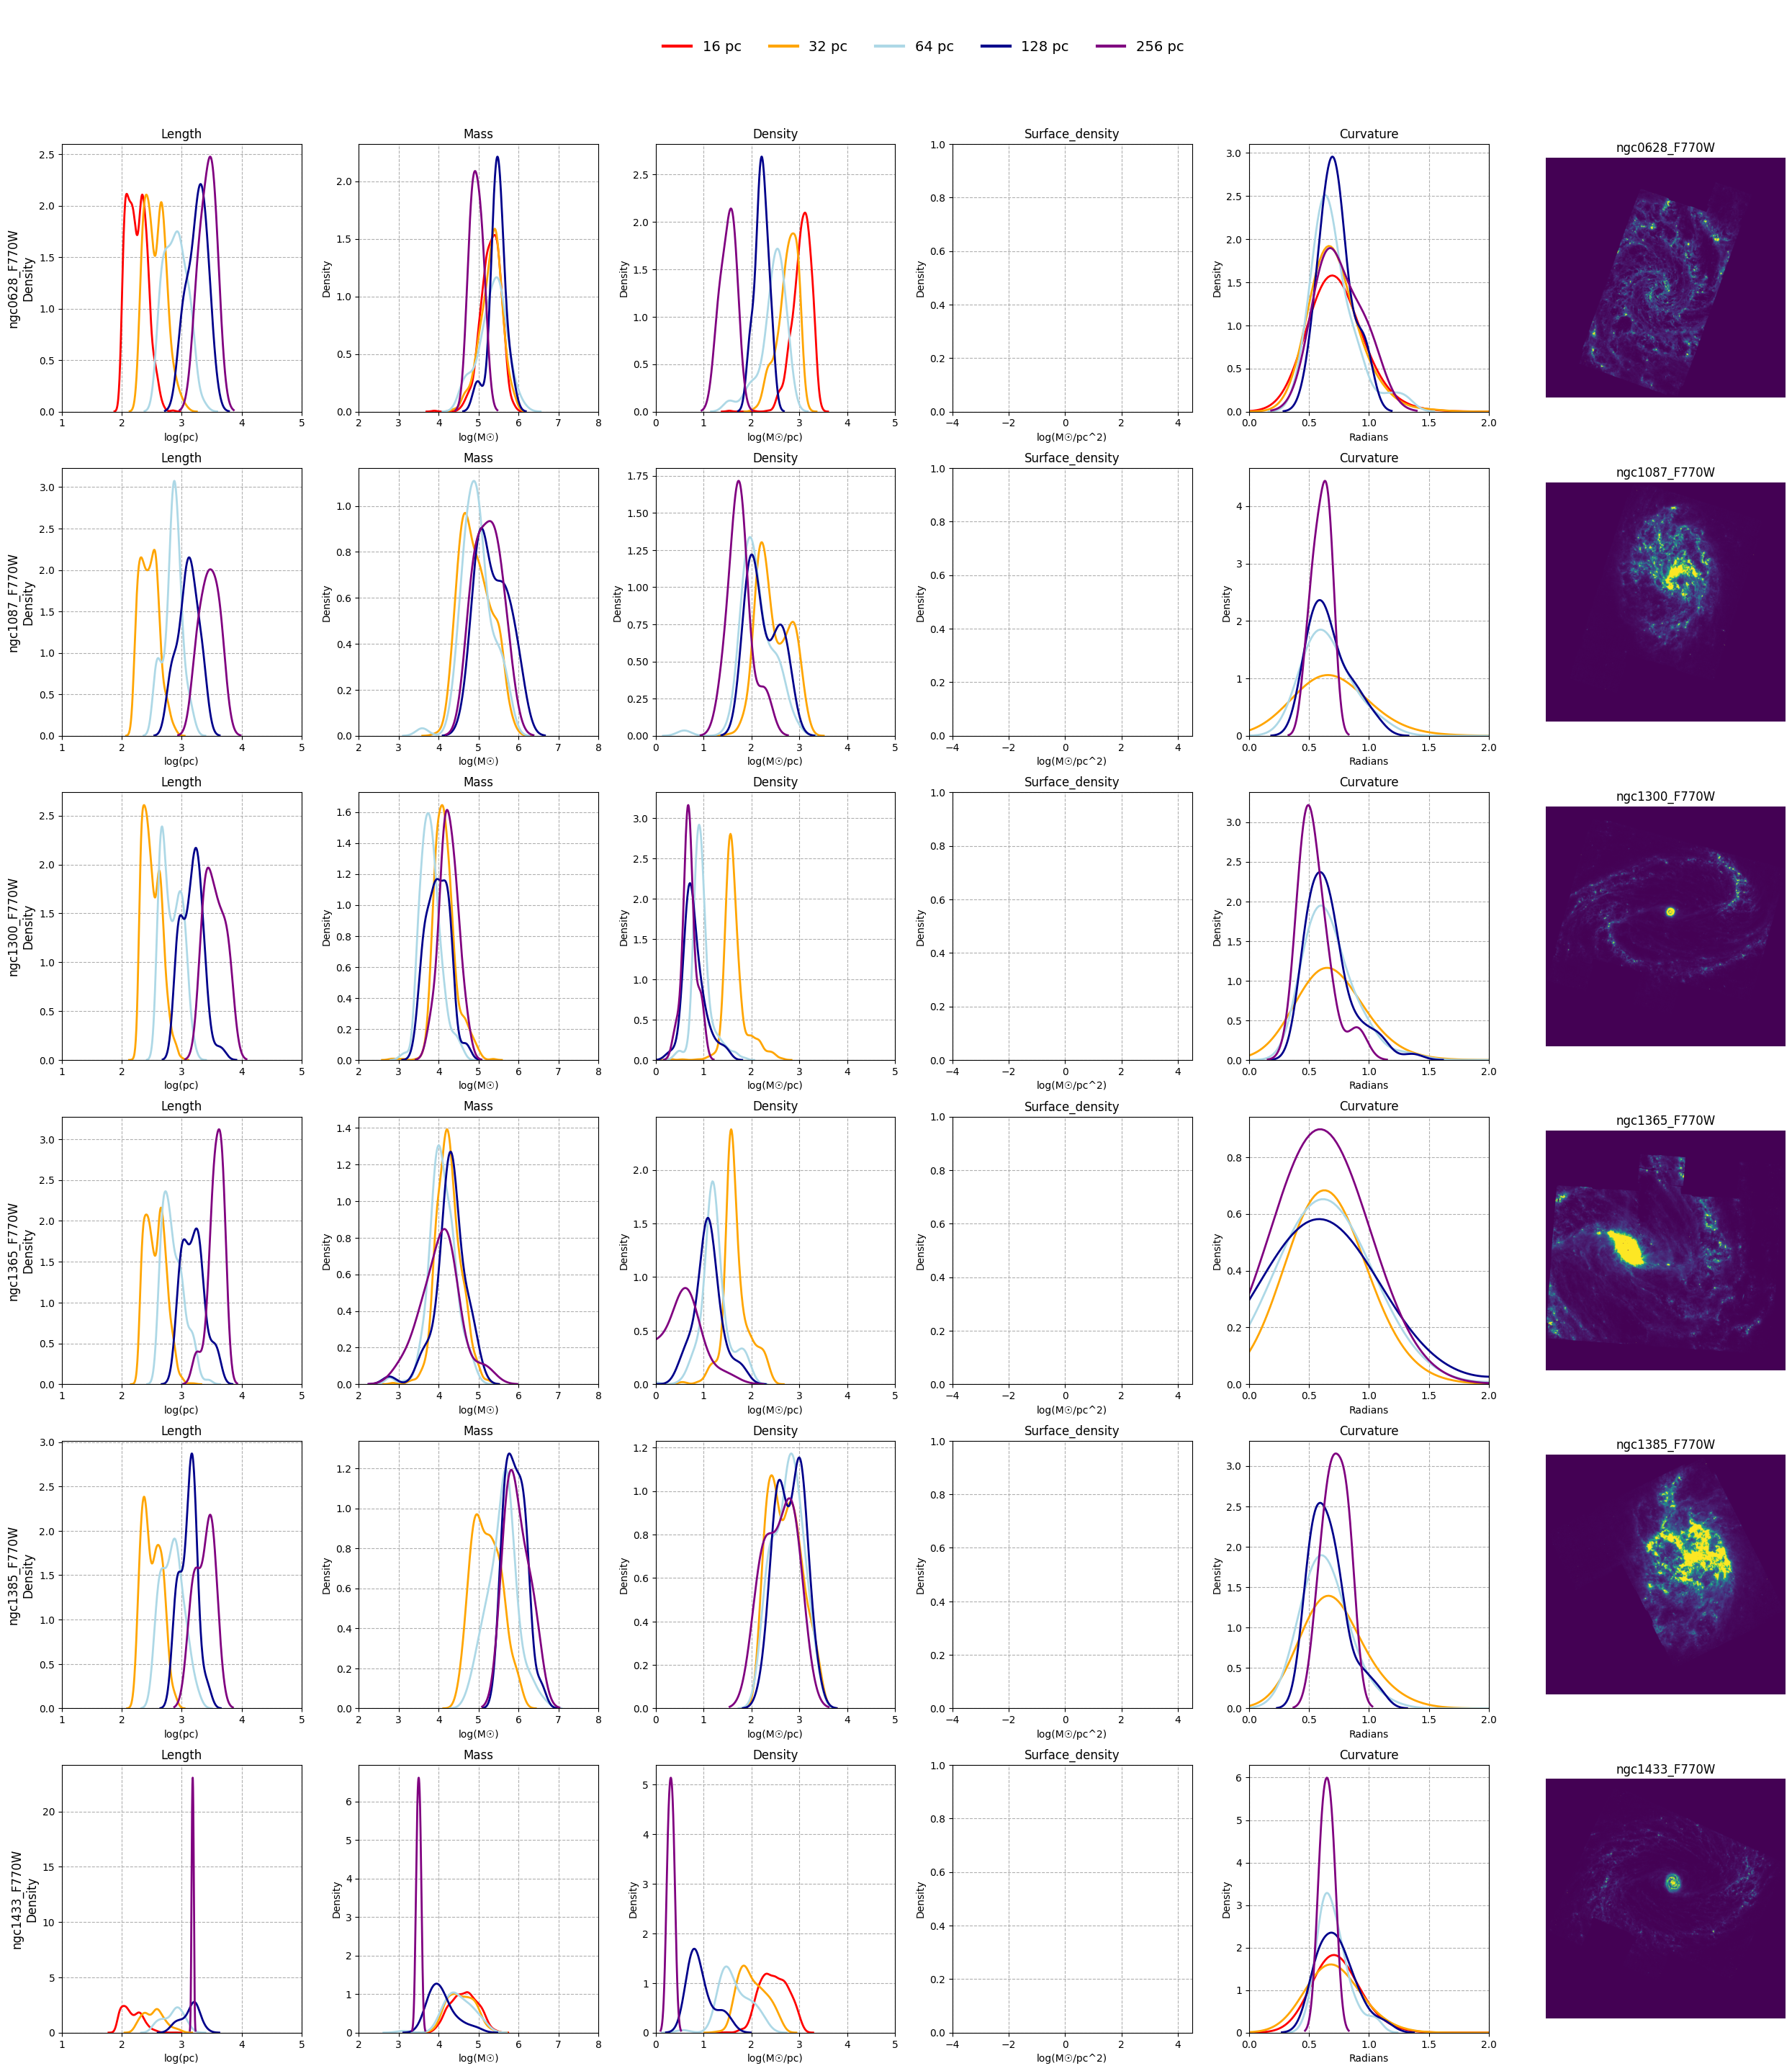

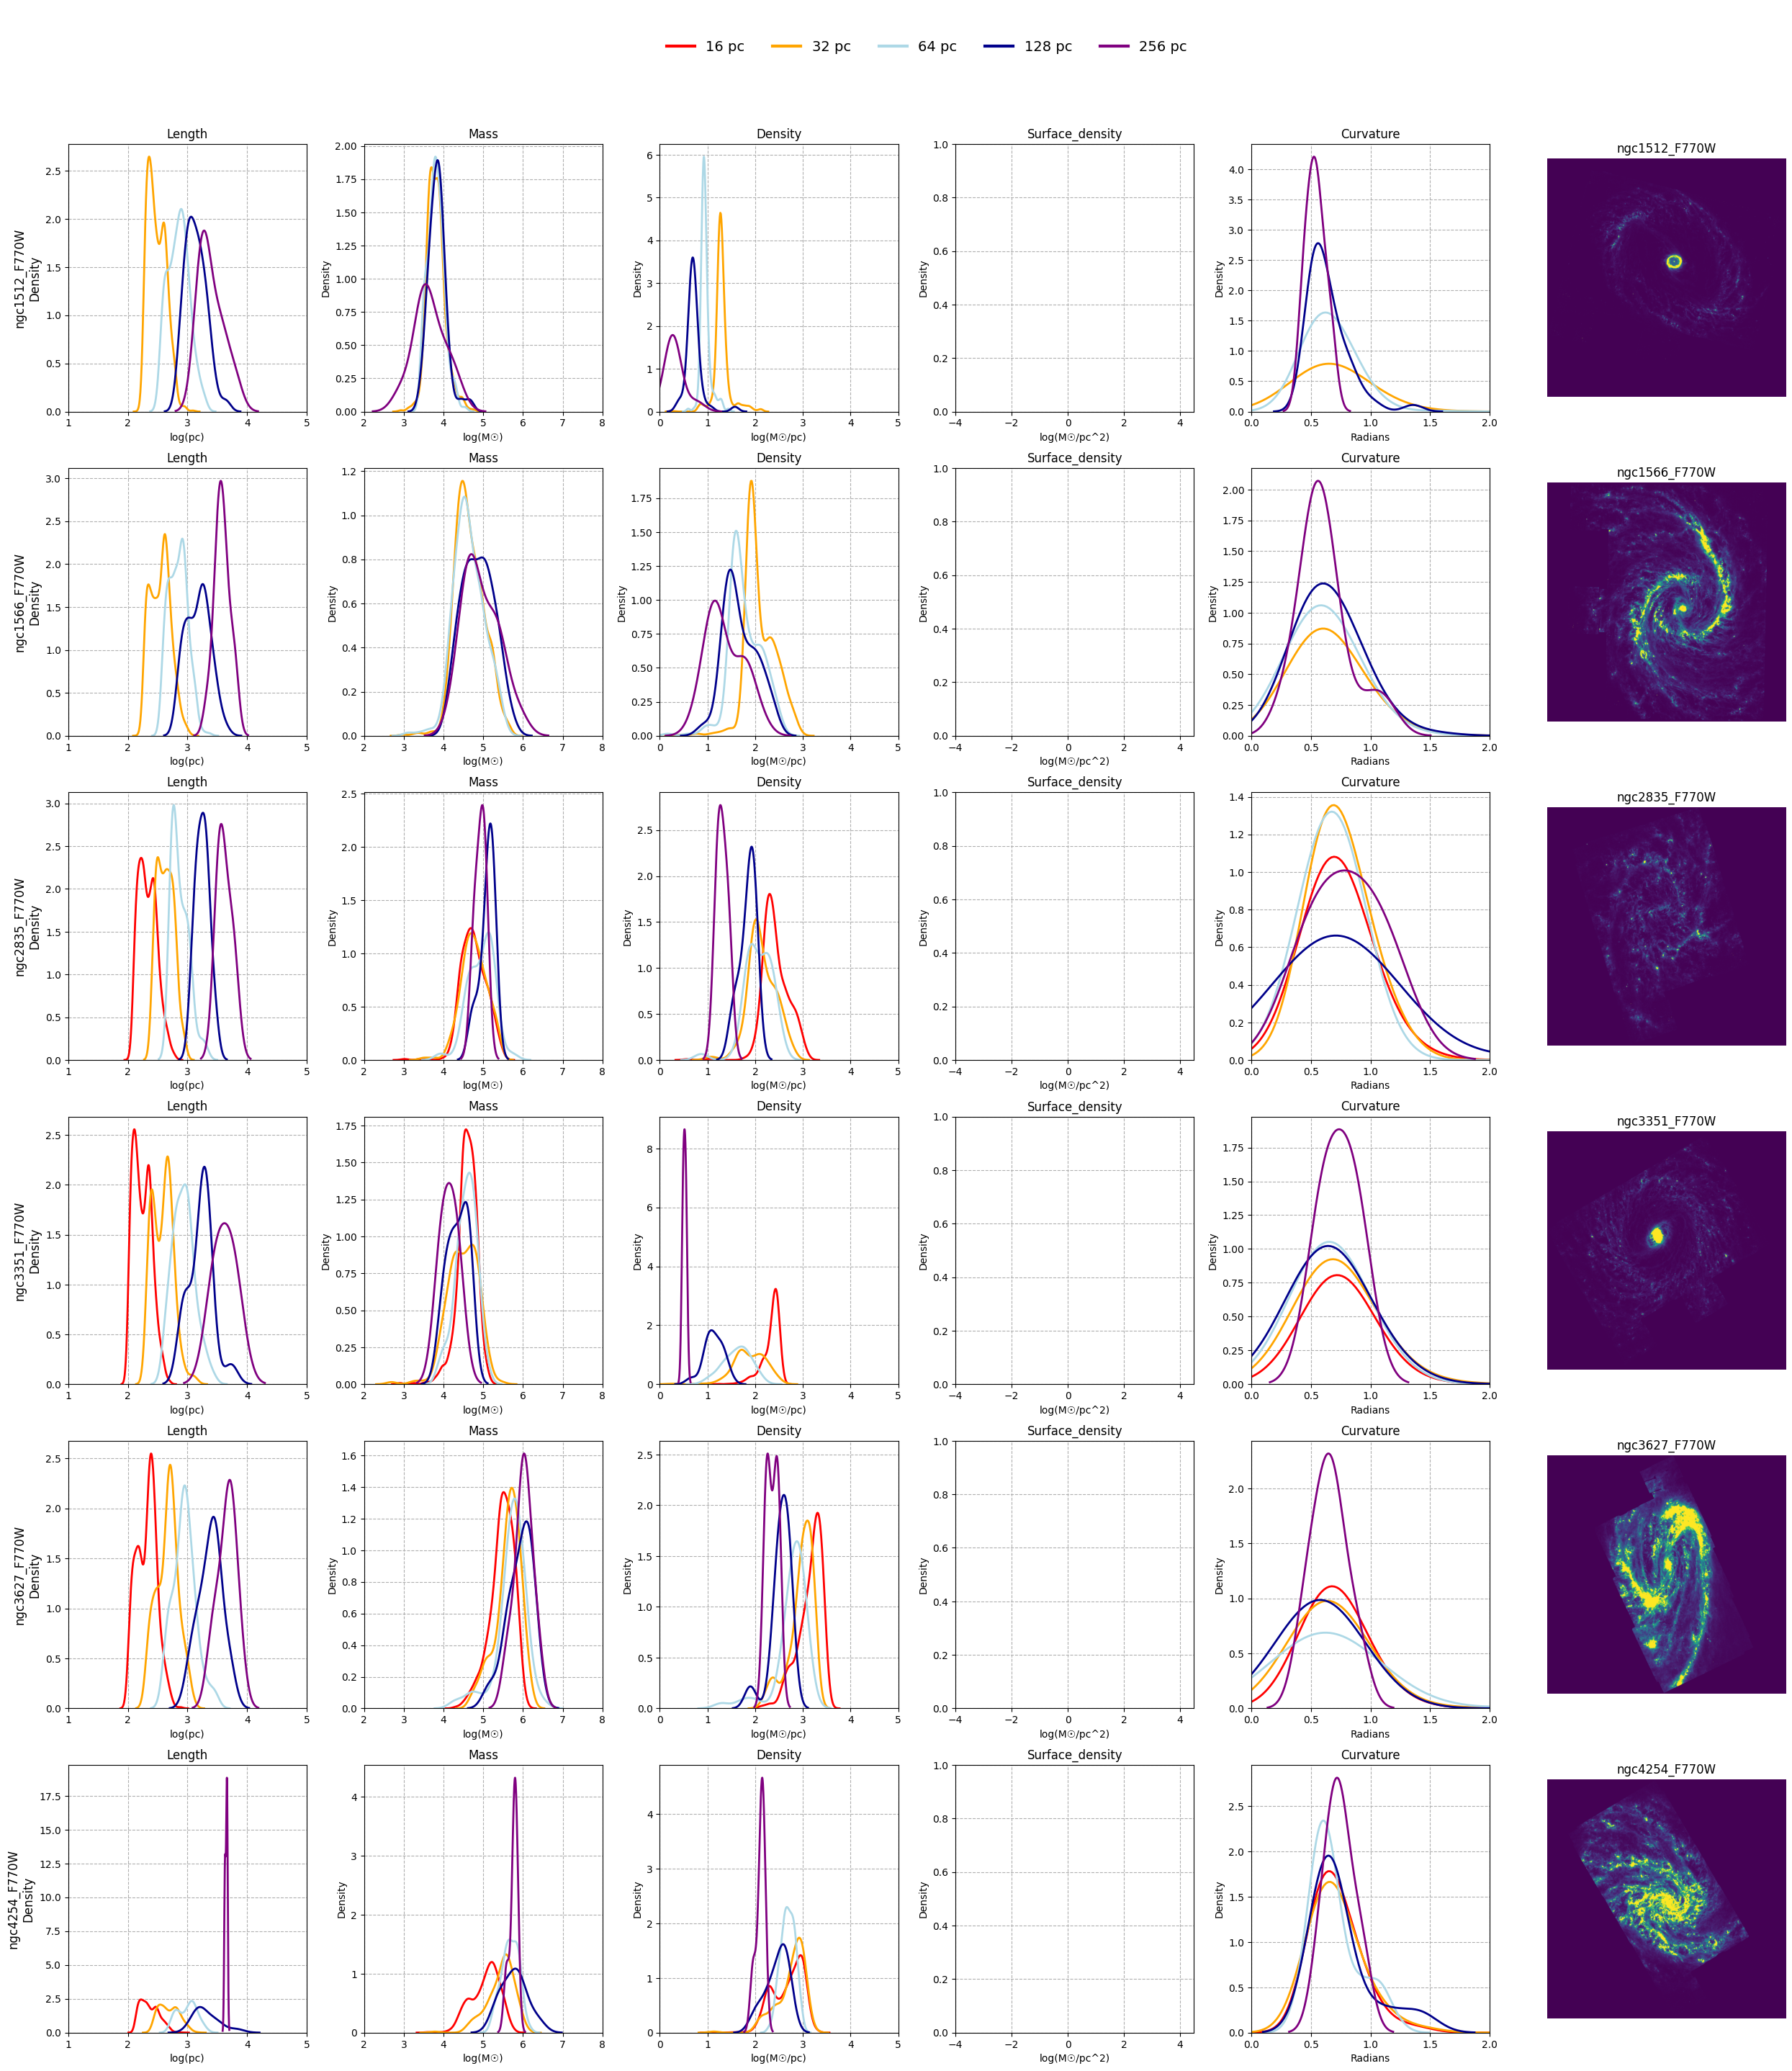

C:\Users\jhoffm72\AppData\Local\Temp\ipykernel_27748\3326310998.py:131: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(plot_data, label=f"{scale} pc", linewidth=2, color=color, ax=ax)
C:\Users\jhoffm72\AppData\Local\Temp\ipykernel_27748\3326310998.py:131: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(plot_data, label=f"{scale} pc", linewidth=2, color=color, ax=ax)


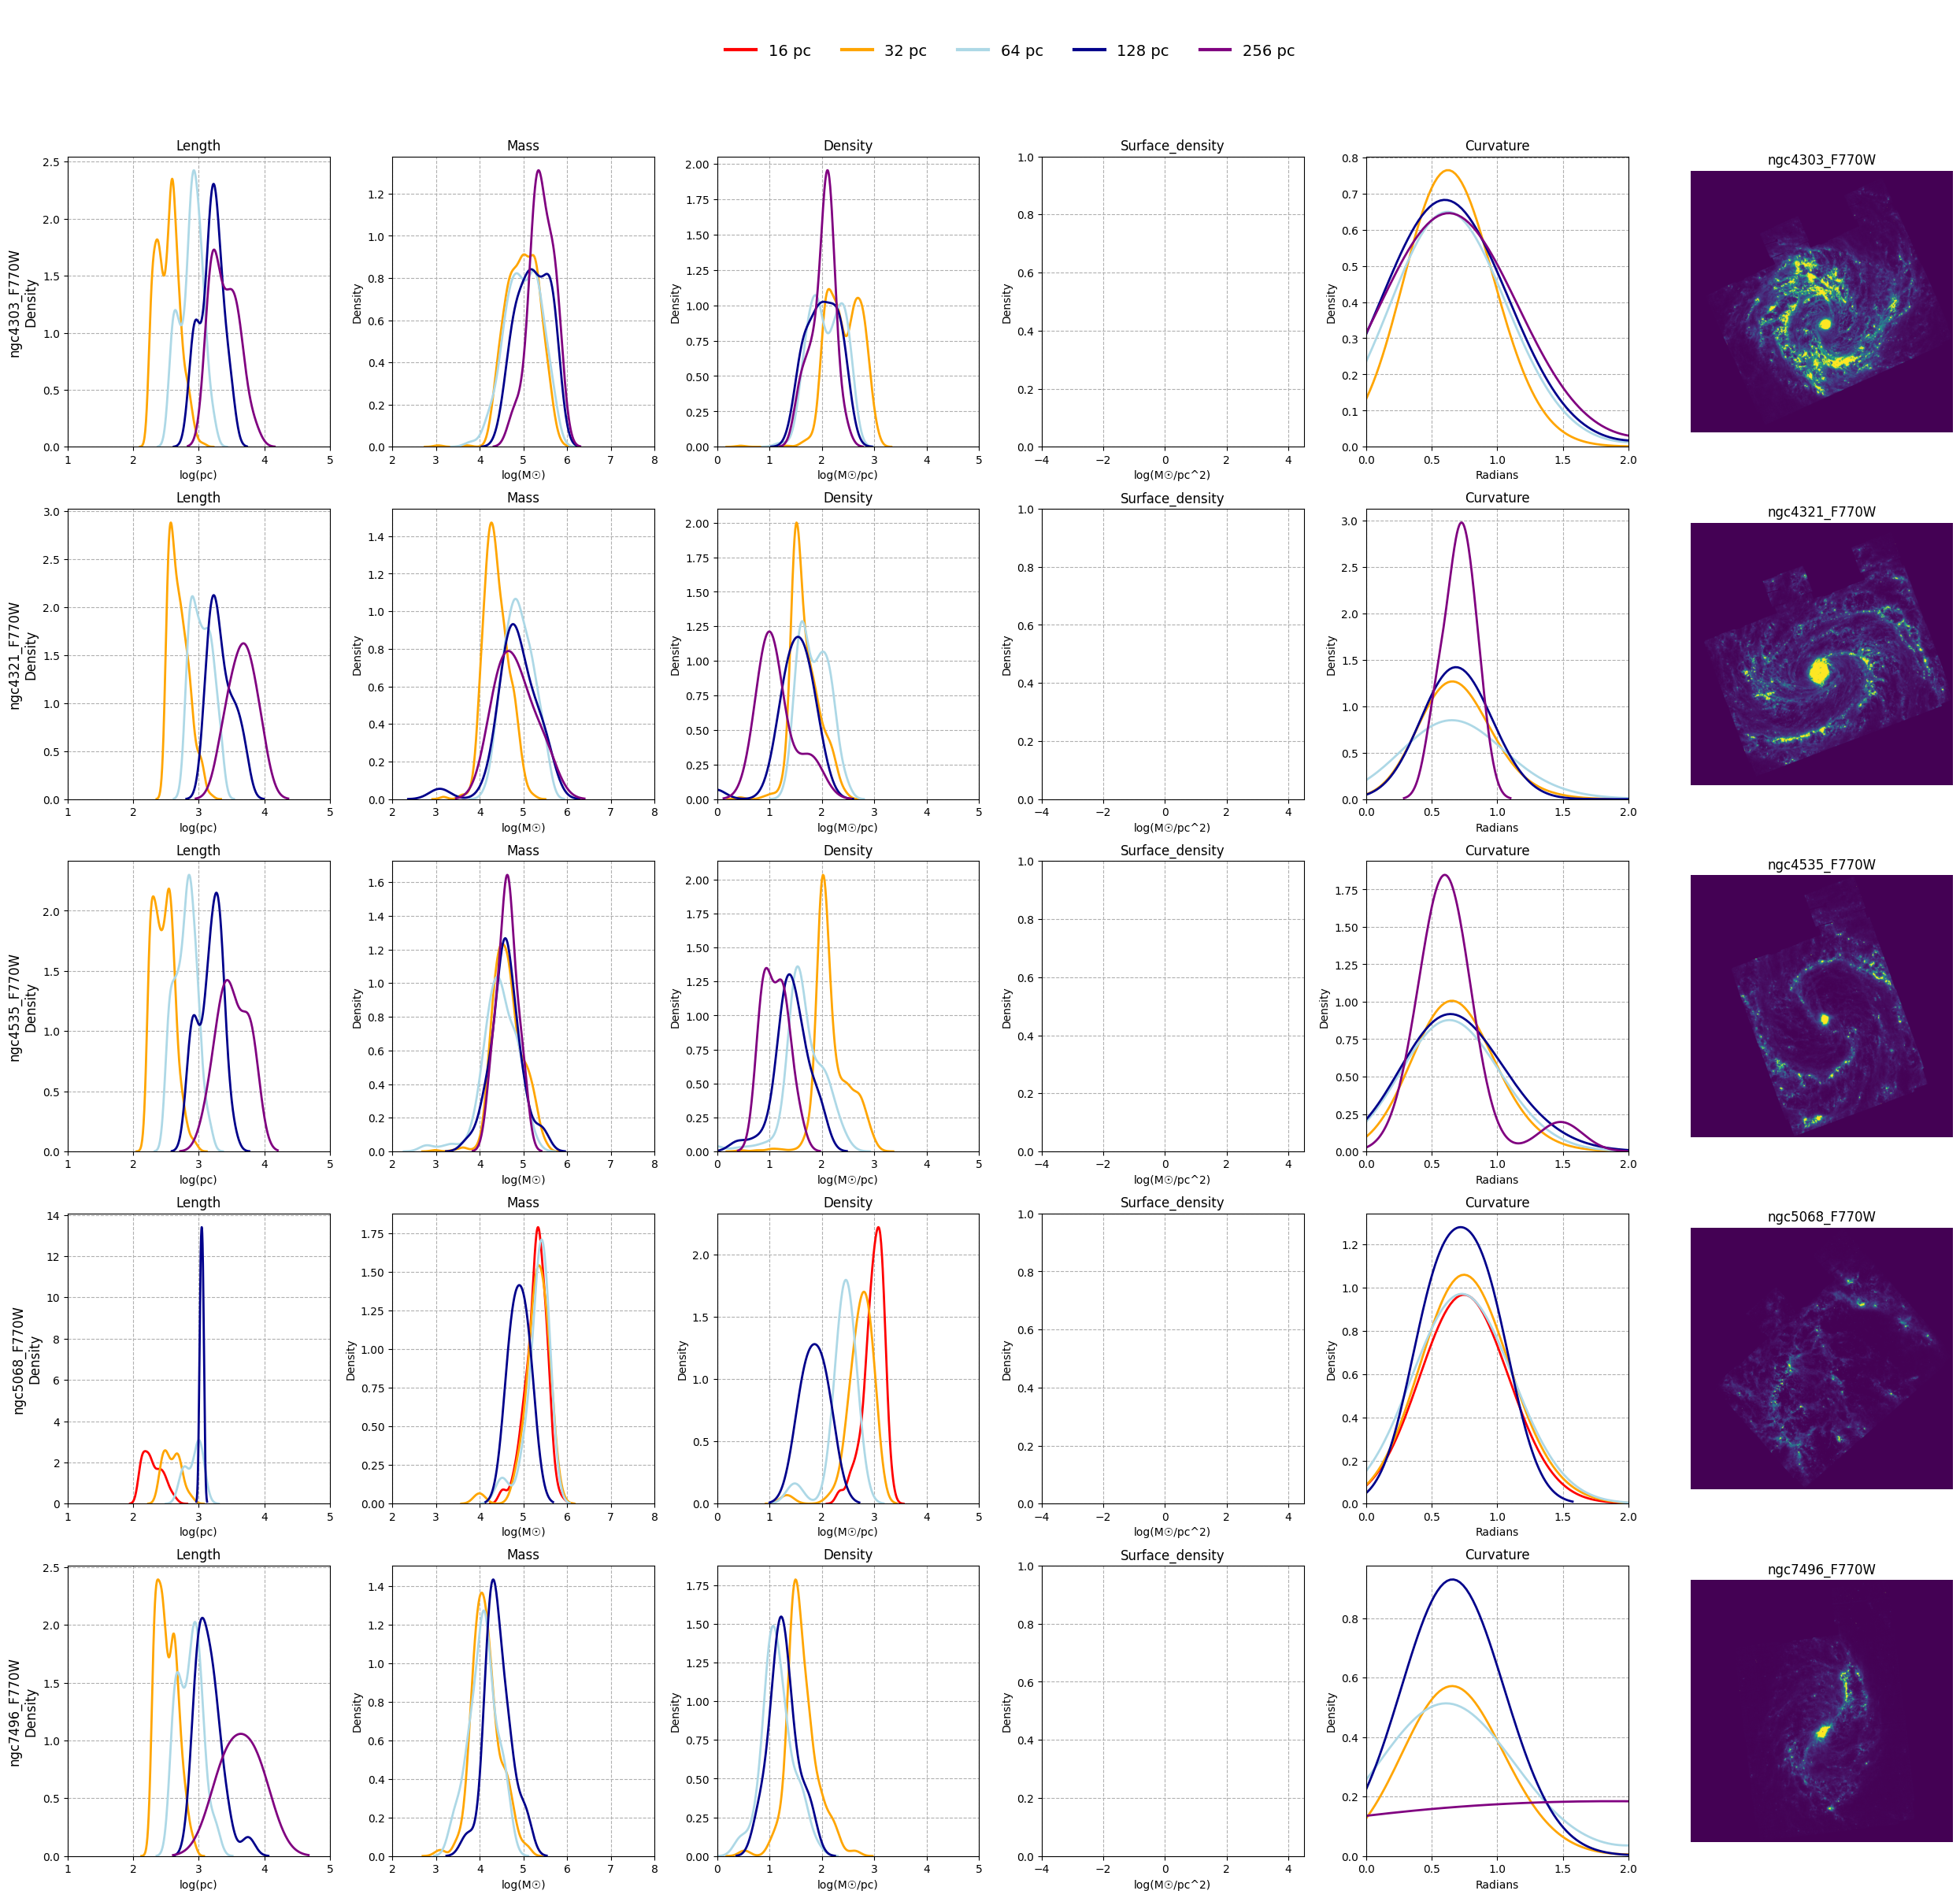

['ngc0628_F770W', 'ngc1087_F770W', 'ngc1300_F770W', 'ngc1365_F770W', 'ngc1385_F770W', 'ngc1433_F770W', 'ngc1512_F770W', 'ngc1566_F770W', 'ngc2835_F770W', 'ngc3351_F770W', 'ngc3627_F770W', 'ngc4254_F770W', 'ngc4303_F770W', 'ngc4321_F770W', 'ngc4535_F770W', 'ngc5068_F770W', 'ngc7496_F770W']


In [4]:
# Base paths
base_dir = Path(r"C:\Users\jhoffm72\Documents\FilPHANGS\Data")
csv_path = Path(r"C:\Users\jhoffm72\Documents\FilPHANGS\Data\ImageData.xlsx")
fits_folder = base_dir / "OriginalImages"
output_folder = base_dir / "Figures"
output_folder.mkdir(exist_ok=True)
Num_Galaxies = 15
Galaxies_per_figure = 6


# Filter valid galaxy folders
galaxy_folders = [
    folder for folder in os.listdir(base_dir)
    if os.path.isdir(base_dir / folder)
    and folder not in ['Figures', 'OriginalImages', 'masks_v5_simple', 'IC5146_PSW']
    and not folder.endswith('.txt') and not folder.endswith('.xlsx') and 'F770W' in folder]

valid_galaxies = []
galaxy_data = {}

for folder in galaxy_folders:
    galaxy_name = folder
    synthetic_folder = base_dir / folder / 'SyntheticMap'

    mass_dict = {}
    length_dict = {}
    density_dict = {}
    region_dict = {}
    curvature_dict = {}
    mass_surface = {}
    pixel_regions = []
    try:
        for file in os.listdir(synthetic_folder):
            if not file.endswith(".fits"):
                print(file)

                file_path = os.path.join(synthetic_folder, file)
                if file.endswith(".xlsx"):
                    df = pd.read_excel(file_path, engine='openpyxl')
                elif file.endswith(".xls"):
                    df = pd.read_excel(file_path)
                elif file.endswith(".csv"):
                    df = pd.read_csv(file_path)
                else:
                    continue

                scale = getScale(file_path)
                print(f'scale: {scale}')
                if scale is None:
                    continue

                try:
                    regions = df[f"Regions_{scale}.0"]
                    mass = df[f'Mass_{scale}.0']
                    Line_Density = df[f'Line_Density_{scale}.0'] #* (int(min_scale)/int(scale))
                    lengths = df[f'Length_{scale}.0'] #* (int(scale)/int(min_scale))
                    mass_dict[scale] = np.array(mass)
                    length_dict[scale] = np.array(lengths)
                    density_dict[scale] = np.array(Line_Density)
                    region_dict[scale] = np.array(regions)
                    curvature_col_name = f'Curvature_{scale}.0'

                    if curvature_col_name not in df.columns:
                        print(f"ERROR: Column '{curvature_col_name}' not found in dataframe!")
                        print(f"Available columns: {[col for col in df.columns if scale in col]}")
                        continue
                
                    curvature = df[curvature_col_name]
                    curvature_values = []

                    for i, s in enumerate(curvature):
                        if pd.isna(s):
                            continue
                        try:
                            if isinstance(s, (int, float, np.number)):
                                curvature_values.append(float(s))
                            elif isinstance(s, str):
                                numeric_part = s.split()[0]
                                curvature_values.append(float(numeric_part))
                            else:
                                print(f"Unexpected type at index {i}: {type(s)} - {s}")
                        except (ValueError, AttributeError) as e:
                            print(f"Error processing index {i}: {s} - {e}")
                            continue
                    

                    curvature_dict[scale] = np.array(curvature_values)

                except (KeyError, ValueError) as e:
                    print(f"Error: for {galaxy_name}", e)
                    continue

                try:
                    if not sr:
                        surface_density_path = base_dir / folder / 'Molecular_Mass'
                        # RegionData = np.array(getRegionData(folder, OrigData, OrigHeader))
                        distance_Mpc, _, pixscale, _, _, _, _, _ = getInfo(galaxy_name, csv_path)
                        ScalePix = pixscale * 4.848 * distance_Mpc
                        for fname in os.listdir(surface_density_path):
                            file = os.path.join(surface_density_path, fname)
                            if not file.lower().endswith(('.fits', '.fit', '.fz')) or not os.path.isfile(file):
                                continue
                            try:
                                scale = getScale(file)
                                assert(scale != None)

                                with fits.open(file, ignore_missing=True) as hdul:
                                    if hdul[0].data is None:
                                        print(f"No data in primary HDU for {file}")
                                        continue
                                    OrigData = np.array(hdul[0].data)
                                    OrigHeader = hdul[0].header
                                bf = int(scale)/16
                                surface_density_data = np.array(OrigData.flatten()) / ((bf*ScalePix)**2)  #pixel mass/pixel area 

                                # filtered_regions = RegionData.flatten()[mask]  # Use the same boolean mask
                                # pixel_regions = filtered_regions
                                pixel_Regions = None
                                mass_surface[scale] = surface_density_data
                                print(f'molecular mass scale: {scale}')
                            except Exception as e:
                                print(f"Error: for {galaxy_name}", e)
                                continue

                except Exception as e:
                    print(f"Error: for {galaxy_name}", e)
                    continue

        if length_dict:
            valid_galaxies.append(galaxy_name)
            galaxy_data[galaxy_name] = {
                "mass": mass_dict,
                "length": length_dict,
                "density": density_dict,
                'region': region_dict,
                'curvature': curvature_dict,
                'surface_density': mass_surface,
                'pixel_regions' : pixel_regions
            }
    except Exception as e:
        print("Error:", e)
        

sr = False
plot_galaxies_subset(valid_galaxies[:Galaxies_per_figure], "First6Galaxies_Summary.png", fits_folder, galaxy_data, output_folder,sort_region = sr)
plot_galaxies_subset(valid_galaxies[Galaxies_per_figure:2*Galaxies_per_figure], "Middle6Galaxies_Summary.png",fits_folder, galaxy_data, output_folder, sort_region =sr)
plot_galaxies_subset(valid_galaxies[2*Galaxies_per_figure:], "Last6Galaxies_Summary.png",fits_folder, galaxy_data, output_folder, sort_region = sr)
print(valid_galaxies)


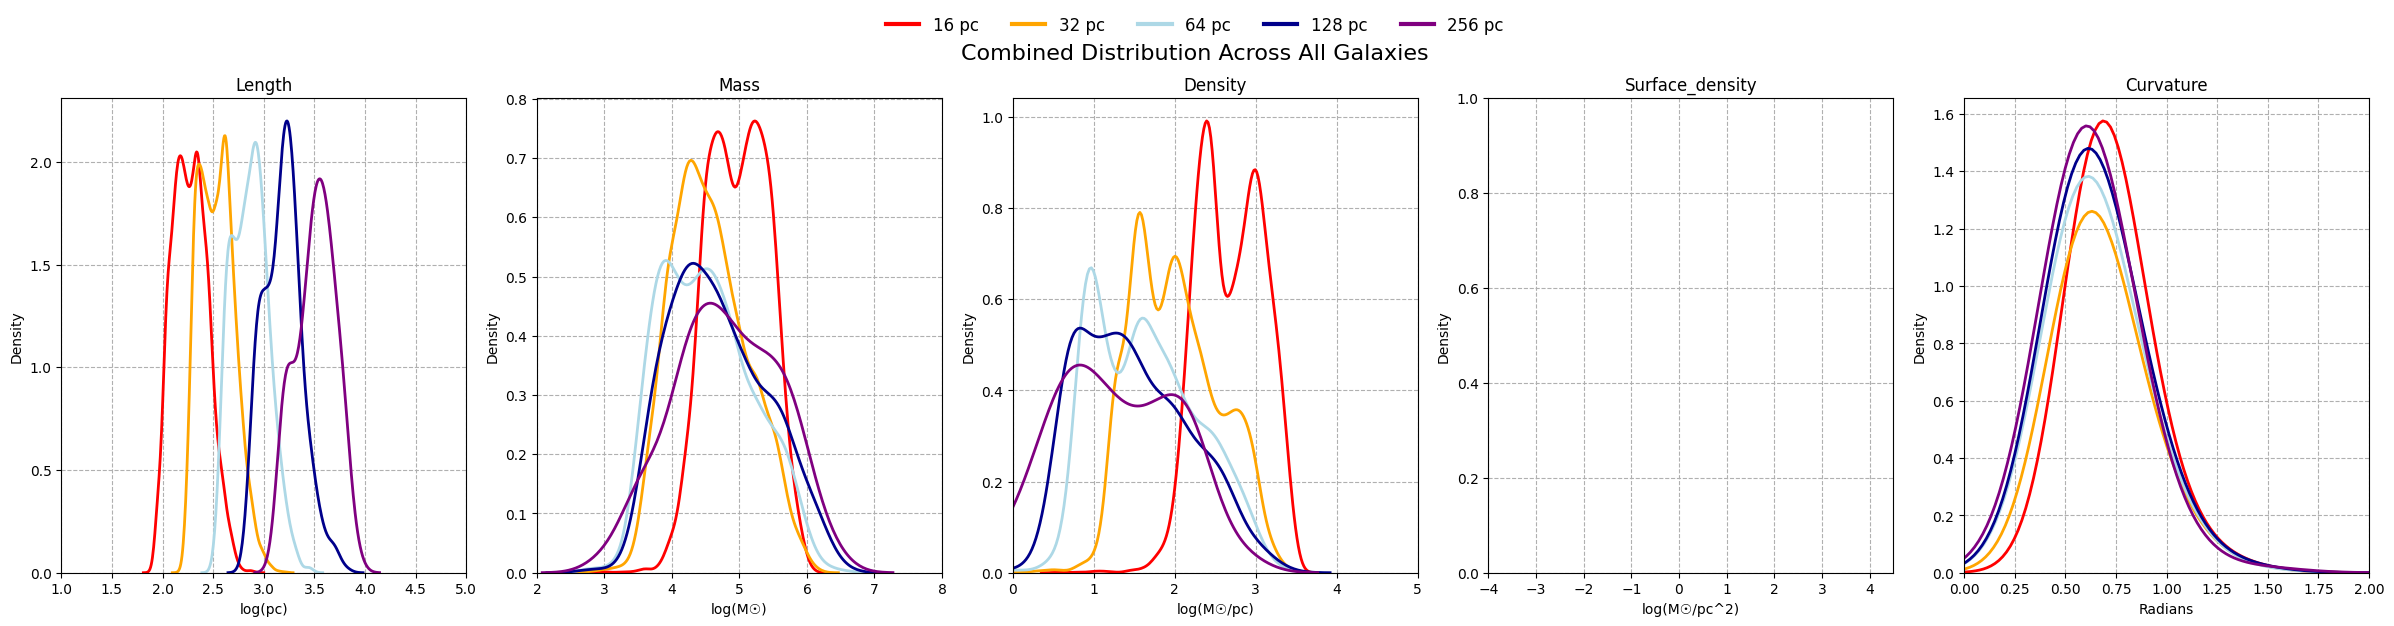

In [5]:
# Combine data across all galaxies. TO FIX!
# Define the scales and initialize the master dict
scales = ['8', "16", "32", "64", "128", "256"]
quantities = ["mass", "length", "density", "surface_density", "curvature", "aspect"]
master_dict = {q: {scale: [] for scale in scales} for q in quantities}

# Combine data across all galaxies
for galaxy in valid_galaxies:
    mass_data = galaxy_data[galaxy]["mass"]
    length_data = galaxy_data[galaxy]["length"]
    density_data = galaxy_data[galaxy]["density"]
    curvature_data = galaxy_data[galaxy]["curvature"]
    surface_density_data = galaxy_data[galaxy]["surface_density"]
    for scale in scales:
        try:
            master_dict["mass"][scale].append(mass_data[scale])
            master_dict["length"][scale].append(length_data[scale])
            master_dict["density"][scale].append(density_data[scale])
            master_dict["curvature"][scale].append(curvature_data[scale])
            master_dict["surface_density"][scale].append(surface_density_data[scale])

        except KeyError:
            # Skip if this galaxy doesn't have data for this scale
            continue

# Convert lists of arrays into flat numpy arrays
for quantity in master_dict:
    for scale in master_dict[quantity]:
        if master_dict[quantity][scale]:  # Avoid empty lists
            combined = np.concatenate(master_dict[quantity][scale])
            master_dict[quantity][scale] = np.array(combined, dtype=np.float64)
        else:
            master_dict[quantity][scale] = np.array([], dtype=np.float64)
            
fig, axes = plt.subplots(1, 5, figsize=(24, 6))            
plot_quantity(master_dict["length"], "length", axes[0])
plot_quantity(master_dict["mass"], "mass", axes[1])
plot_quantity(master_dict["density"], "density", axes[2])
plot_quantity(master_dict["surface_density"], "surface_density", axes[3])
plot_quantity(master_dict["curvature"], "curvature", axes[4])  # <-- was axes[3]


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=color, lw=3)
    for scale, color in sorted(scale_colors.items(), key=lambda x: float(x[0]))
]
fig.legend(
    handles=legend_elements,
    labels=[f"{scale} pc" for scale in sorted(scale_colors, key=float)],
    loc='upper center', bbox_to_anchor=(0.5, 1.05),
    ncol=len(scale_colors), fontsize=12, frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle("Combined Distribution Across All Galaxies", fontsize=16)

# Save the plot
final_combined_path = output_folder / "AllGalaxies_Combined_Corrected.png"
fig.savefig(final_combined_path, dpi=300, bbox_inches='tight')
fig.savefig(final_combined_path.with_suffix(".pdf"), format='pdf', bbox_inches='tight')
plt.show()

     Unnamed: 0  log Length  log Mass     Line Mass      Thermal        Total  \
0             0    3.707421  7.685709   9512.353911   322.827850   679.279011   
1             1    2.873068  6.289390   2608.086553   378.126146   510.704268   
2             2    3.567740  7.758320  15508.864443   290.690112  1029.269964   
3             3    2.083286  4.811025    534.243196          NaN          NaN   
4             4    1.522798  3.544882    105.216536   830.585902   830.733407   
..          ...         ...       ...           ...          ...          ...   
474         474    1.481189  3.544086    115.583808  1118.073781  1118.073781   
475         475    2.761364  6.170946   2567.923017   593.621094   663.968721   
476         476    2.034317  4.187437    142.272185   942.552743   945.890316   
477         477    2.149311  4.561388    258.271806   695.142824   694.103858   
478         479    2.607435  5.650614   1104.533774   908.094538  3728.190313   

         Magnetic  
0    10

c:\Users\jhoffm72\Downloads\microConda\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


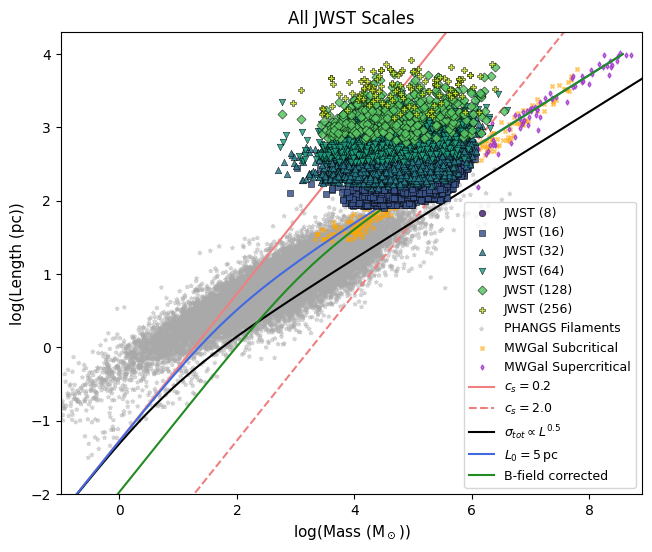

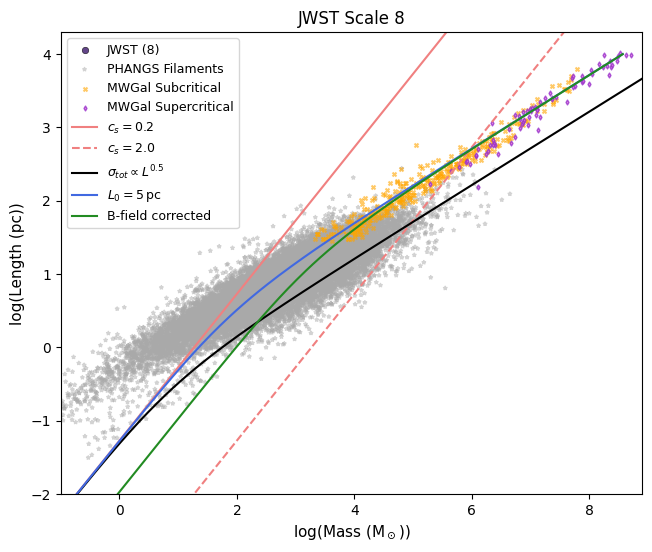

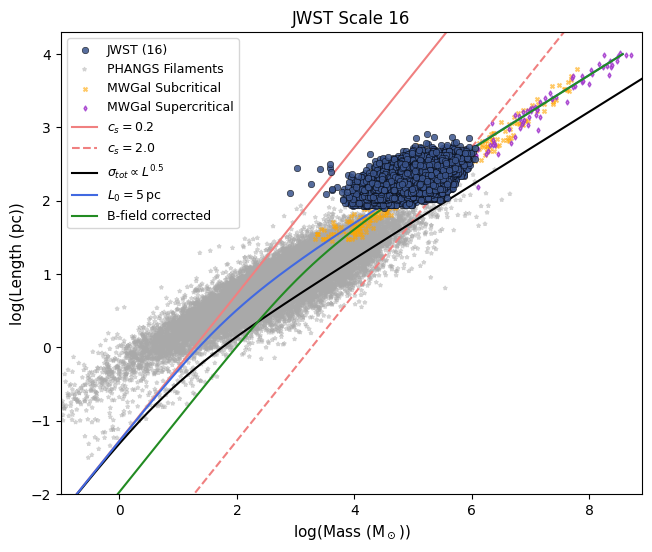

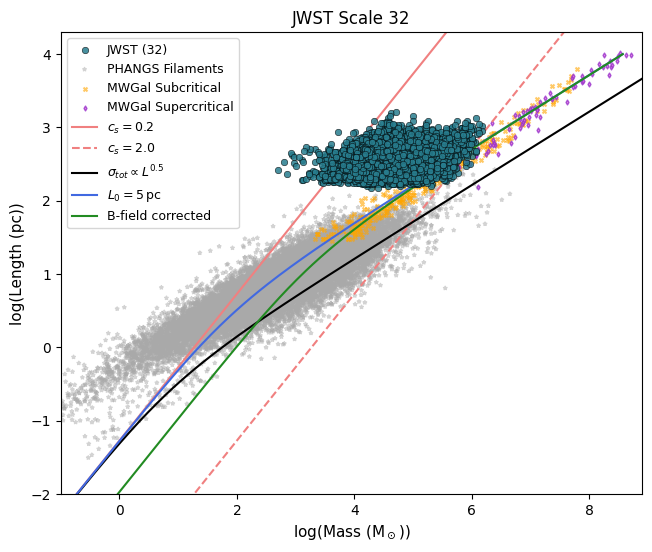

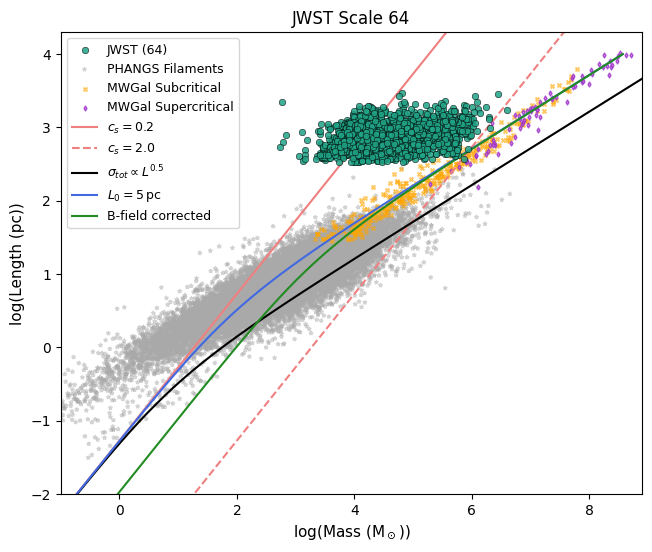

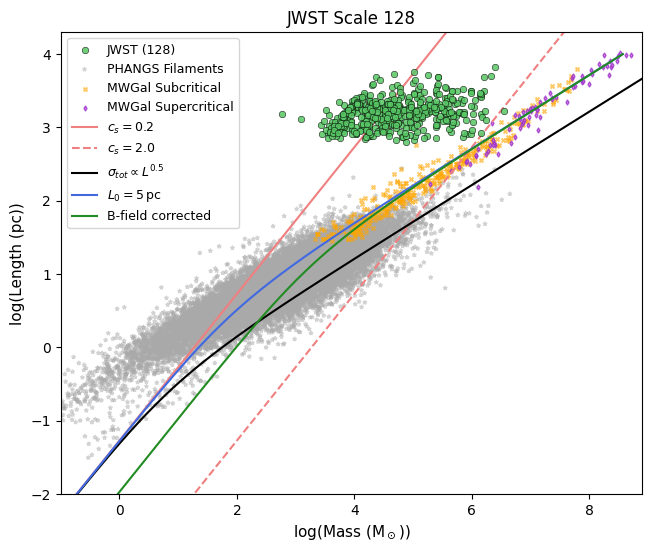

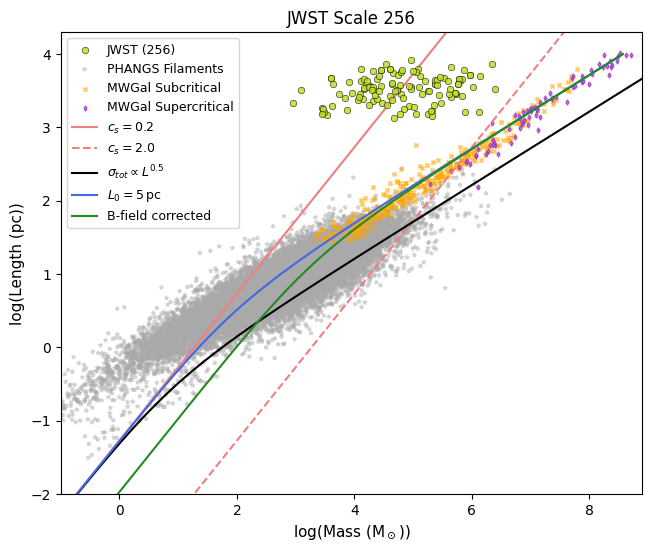

In [6]:
#!/usr/bin/env python
# coding: utf-8

# In[9]:


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
from astropy.io import fits
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

def thermal(cs, M):
    mass = (10**M)*1.989e33
    speed = cs*100000
    L = (mass)*6.67e-8/(2*speed**2)
    return np.log10(L/3.086e18)

def lscale(cs,L, L0):
    speed = cs*100000
    l = (10**L)*3.086e18
    M = ((2*speed**2)/6.67e-8)*l*(1+((10**L)/L0))
    return np.log10(M/1.989e33)

def fBcorr(cs, va, L, L0):
    speed = cs*100000
    alfven = va*100000
    l = (10**L)*3.086e18
    M = ((2*speed**2)/6.67e-8)*l*(1+((10**L)/L0)+(alfven/speed)**2)
    return np.log10(M/1.989e33)    

M = np.linspace(-1, 9.0, 200)
L = np.linspace(-2, 4, 200)
cs = [0.2, 2, np.sqrt(0.6**2 + 6**2), 5]
sigtot = [1,4, 8, 12]

path = r"C:\Users\jhoffm72\Documents\FilPHANGS\Data\Fils_obsdata_public.csv"
molFils = pd.read_csv(path)
#print(molFils)

molFils.sort_values(by="REF", axis=0, inplace=True)
molFils.set_index(keys=["REF"], drop=False, inplace=True)


path = r"C:\Users\jhoffm72\Documents\FilPHANGS\Data\simfils_p12025.csv"
simdata = pd.read_csv(path)
print(simdata)


# In[16]:


dataset = molFils["REF"].unique().tolist()
for set in dataset:
    setarr = molFils[molFils["Ncol_cm-2"] < 1e22]

super = simdata[simdata["Line Mass"]/simdata["Magnetic"] >= 1.0]
sub = simdata[simdata["Line Mass"]/simdata["Magnetic"] < 1.0]

linestyles= ["solid","dashed", "dotted", "dashdot", (0, (3, 5, 1, 5, 1, 5))]


jwst_markers = ["o", "s", "^", "v", "D", "P", "X", "*", "<", ">", "h", "8"]

scales = sorted(master_dict["length"], key=lambda x: float(x))
colors = cm.viridis(np.linspace(0.1, 0.9, len(scales)))

# ===============================
# Plotting helper
# ===============================

def make_plot(jwst_scales_to_plot, title_suffix="", save=True):
    plt.figure(figsize=(7.5, 6))

    # JWST
    for i, scale in enumerate(jwst_scales_to_plot):
        m = np.array(master_dict["mass"][scale])
        l = np.array(master_dict["length"][scale])

        # try:
        #     m = np.array(galaxy_data['ngc0628_F770W']['mass'][scale])
        #     print(m)
        #     l = np.array(galaxy_data['ngc0628_F770W']['length'][scale])
        # except:
        #     continue


        mask = (m > 0) & (l > 0)

        plt.scatter(
            np.log10(m[mask]),
            np.log10(l[mask]),
            s=22,
            marker=jwst_markers[i % len(jwst_markers)],
            color=colors[scales.index(scale)],
            edgecolors="black",
            linewidths=0.4,
            alpha=0.85,
            label=f"JWST ({scale})",
            zorder=10
        )

    # Observations
    plt.scatter(
        np.log10(molFils["Mass_Msun"]),
        np.log10(molFils["L_pc"]),
        s=7,
        marker="*",
        facecolors="none",
        edgecolors="darkgray",
        alpha=0.5,
        label="PHANGS Filaments"
    )

    plt.scatter(
        sub["log Mass"],
        sub["log Length"],
        s=8,
        marker="x",
        color="orange",
        alpha=0.6,
        label="MWGal Subcritical"
    )

    plt.scatter(
        super["log Mass"],
        super["log Length"],
        s=6,
        marker="d",
        color="orchid",
        edgecolor="darkorchid",
        alpha=0.8,
        label="MWGal Supercritical"
    )

    # Theory
    plt.plot(M, thermal(0.2, M), c="lightcoral",
             linestyle=linestyles[0], label=r"$c_s = 0.2$")
    plt.plot(M, thermal(2.0, M), c="lightcoral",
             linestyle=linestyles[1], label=r"$c_s = 2.0$")

    plt.plot(lscale(0.2, L, 0.5), L, c="black",
             label=r"$\sigma_{tot} \propto L^{0.5}$")

    plt.plot(lscale(0.2, L, 5.0), L, c="royalblue",
             label=r"$L_0 = 5\,\mathrm{pc}$")

    plt.plot(fBcorr(0.2, 0.4, L, 5.0), L,
             c="forestgreen",
             label="B-field corrected")

    # Formatting
    plt.xlabel(r"log(Mass (M$_\odot$))", fontsize=11)
    plt.ylabel("log(Length (pc))", fontsize=11)
    plt.xlim(-1, 8.9)
    plt.ylim(-2, 4.3)
    plt.legend(fontsize=9)
    plt.title(title_suffix)

    if save:
        plt.savefig(f"mass_length_{title_suffix}.png",
                    dpi=300, bbox_inches="tight")

    plt.show()


# ===============================
# Generate plots
# ===============================

# 1) All JWST scales together
make_plot(scales, title_suffix="All JWST Scales")

# 2) One plot per JWST scale
for scale in scales:
    make_plot([scale], title_suffix=f"JWST Scale {scale}")



In [7]:
path  = r'c:\Users\jhoffm72\Documents\FilPHANGS\Data\ngc1087_F770W\Molecular_Mass\ngc1087_F770W_JWST_Emission_starsub_CDDss0128pc.fits_MolecularMassMap_Grouped.fits'


def getRegionData(folder, OrigData, OrigHeader):
    """
    Find the appropriate region file and reproject into the size of the original image. 

    Parameters:
    - file (str): The original file path to match galaxy name
    - OrigData: Original data array
    - OrigHeader: Original header

    Returns:
    - data_new (float): region file reprojected into original image shape
    """

    # Look through files in region directory
    dir = r'C:\Users\jhoffm72\Documents\FilPHANGS\Data\masks_v5_simple'
    galaxy = folder.split("_")[0]  # Get galaxy name from file
    # Check if directory exists
    if not os.path.exists(dir):
        print(f"Region directory does not exist: {dir}")
        return np.full(OrigData.shape, np.nan)
    
    for region_file in os.listdir(dir):
        if galaxy.lower() in region_file.lower() and region_file.lower().endswith(('.fits', '.fit', '.fz')):
            fits_path = os.path.join(dir, region_file)
            
            try:
                with fits.open(fits_path, ignore_missing=True) as hdul:
                    data = np.array(hdul[0].data)  # region map
                    header = hdul[0].header

                data_new = reprojectWrapper(data, header, OrigHeader, OrigData)
                return data_new  # return region file reprojected into original file shape
                
            except Exception as e:
                print(f"Error processing region file {region_file}: {e}")
                continue
    
    print(f"No region file found for galaxy {galaxy} in {dir}")
    return np.full(OrigData.shape, np.nan)  # Return array of NaNs if no region file found

with fits.open(path, ignore_missing=True) as hdul:
    OrigData = np.array(hdul[0].data)
    OrigHeader = hdul[0].header
data = getRegionData('ngc1087', OrigData, OrigHeader)

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]


Set DATE-AVG to '2023-01-25T12:03:47.639' from MJD-AVG.
Set DATE-END to '2023-01-25T12:31:47.961' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.605143 from OBSGEO-[XYZ].
Set OBSGEO-H to 1660637438.040 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [8]:
for galaxy in valid_galaxies[:3]:
    for scale in ['16', '32']:
        arr_m = galaxy_data[galaxy]["mass"].get(scale)
        arr_l = galaxy_data[galaxy]["length"].get(scale)
        if arr_m is not None and len(arr_m) > 0:
            print(f"{galaxy} scale={scale}  "
                  f"mass min={arr_m.min():.2f} max={arr_m.max():.2f}  "
                  f"length min={arr_l.min():.2f} max={arr_l.max():.2f}")

ngc0628_F770W scale=16  mass min=0.00 max=914454.56  length min=99.70 max=708.41
ngc0628_F770W scale=32  mass min=0.00 max=795894.83  length min=199.40 max=1206.92
ngc1087_F770W scale=32  mass min=0.00 max=875700.86  length min=160.60 max=819.89
ngc1300_F770W scale=32  mass min=0.00 max=232681.66  length min=172.16 max=992.44


In [9]:
from astropy.io import fits
from pathlib import Path
import numpy as np

mol_mass_path = Path(r"C:\Users\jhoffm72\Documents\FilPHANGS\Data\ngc0628_F770W\Molecular_Mass")

for fits_file in sorted(mol_mass_path.glob("*.fits")):
    try:
        with fits.open(fits_file) as hdul:
            data = hdul[0].data
            if data is None:
                print(f"{fits_file.name}: no data in primary HDU")
                continue
            data = np.array(data, dtype=np.float64)
            finite_data = data[np.isfinite(data)]
            total = np.sum(finite_data)
            if total > 0:
                print(f"{fits_file.name}: sum = {total:.4e},  log10(sum) = {np.log10(total):.4f}")
            else:
                print(f"{fits_file.name}: sum = {total:.4e}  (non-positive, can't log)")
    except Exception as e:
        print(f"{fits_file.name}: ERROR — {e}")

ngc0628_F770W_JWST_Emission_starsub_CDDss0016pc.fits_MolecularMassMap_Grouped.fits: sum = 2.5478e+07,  log10(sum) = 7.4062
ngc0628_F770W_JWST_Emission_starsub_CDDss0016pc.fits_MolecularMassMap_NotGrouped.fits: sum = 2.1124e+07,  log10(sum) = 7.3248
ngc0628_F770W_JWST_Emission_starsub_CDDss0032pc.fits_MolecularMassMap_Grouped.fits: sum = 7.6547e+06,  log10(sum) = 6.8839
ngc0628_F770W_JWST_Emission_starsub_CDDss0064pc.fits_MolecularMassMap_Grouped.fits: sum = 2.2282e+06,  log10(sum) = 6.3479
ngc0628_F770W_JWST_Emission_starsub_CDDss0128pc.fits_MolecularMassMap_Grouped.fits: sum = 5.2166e+05,  log10(sum) = 5.7174
ngc0628_F770W_JWST_Emission_starsub_CDDss0256pc.fits_MolecularMassMap_Grouped.fits: sum = 9.2724e+04,  log10(sum) = 4.9672


Scale 8: no data, skipping.


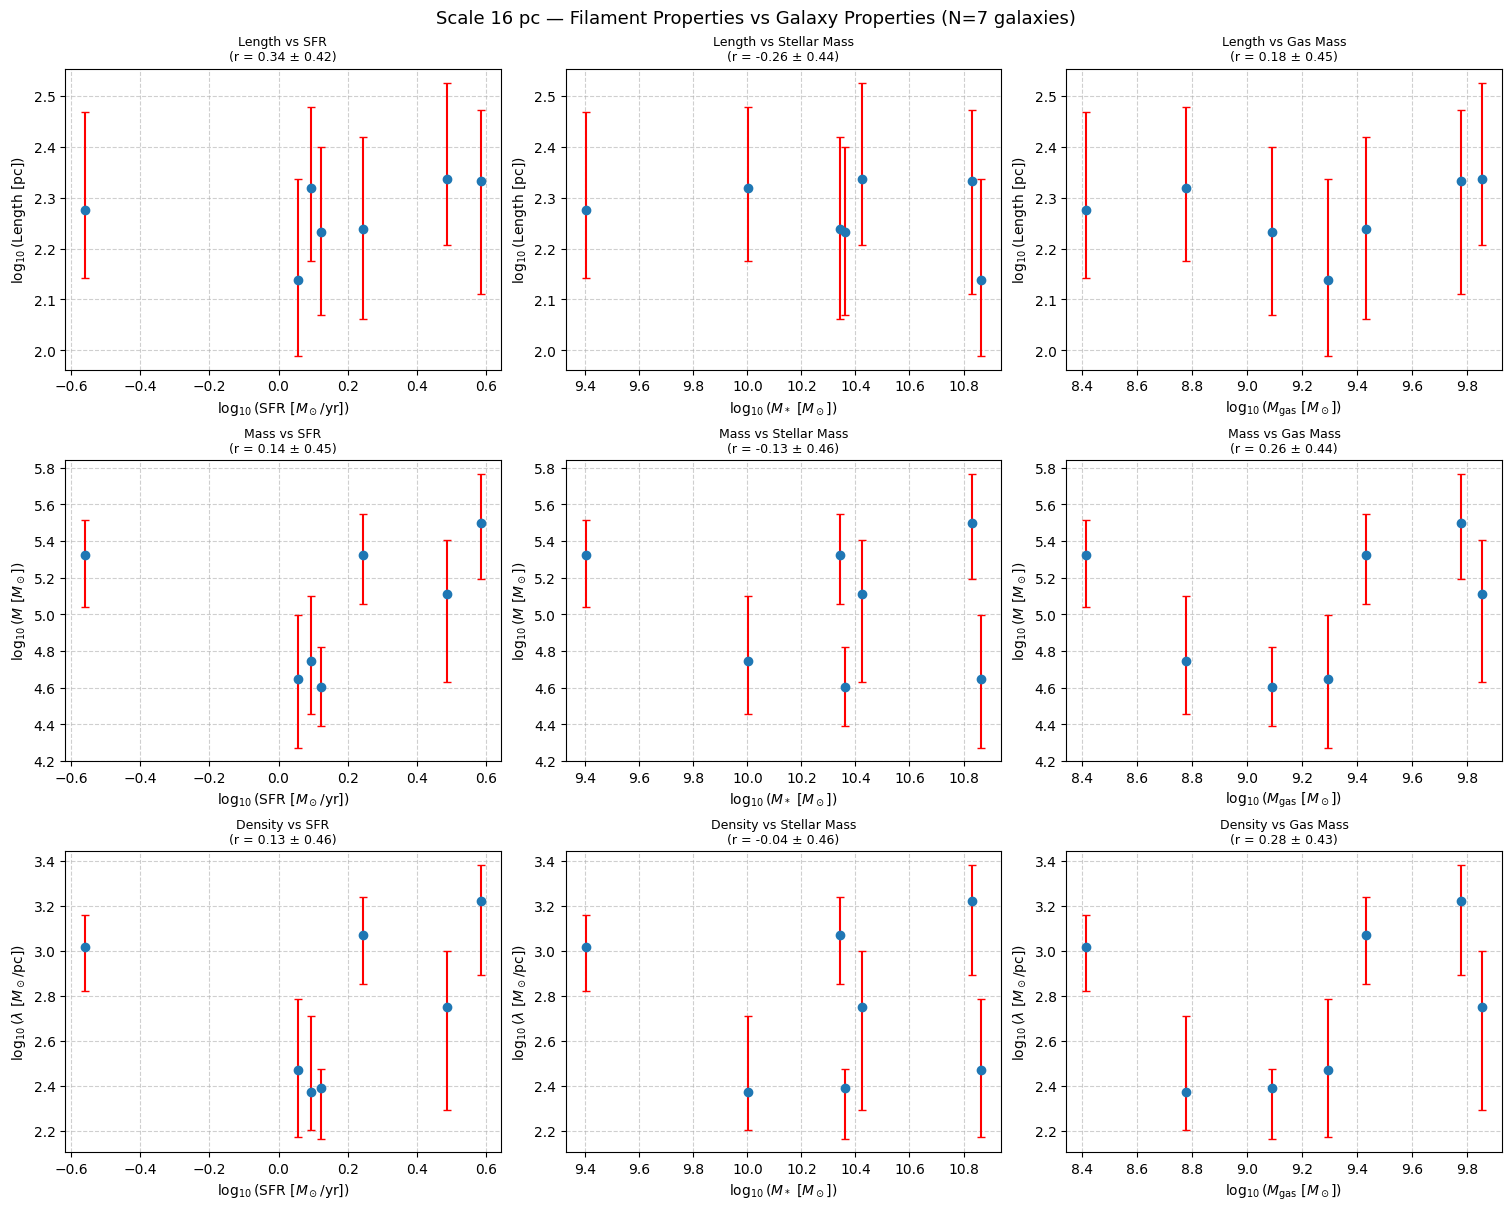

Saved scale 16 → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\scale_16_properties_vs_galaxy.png


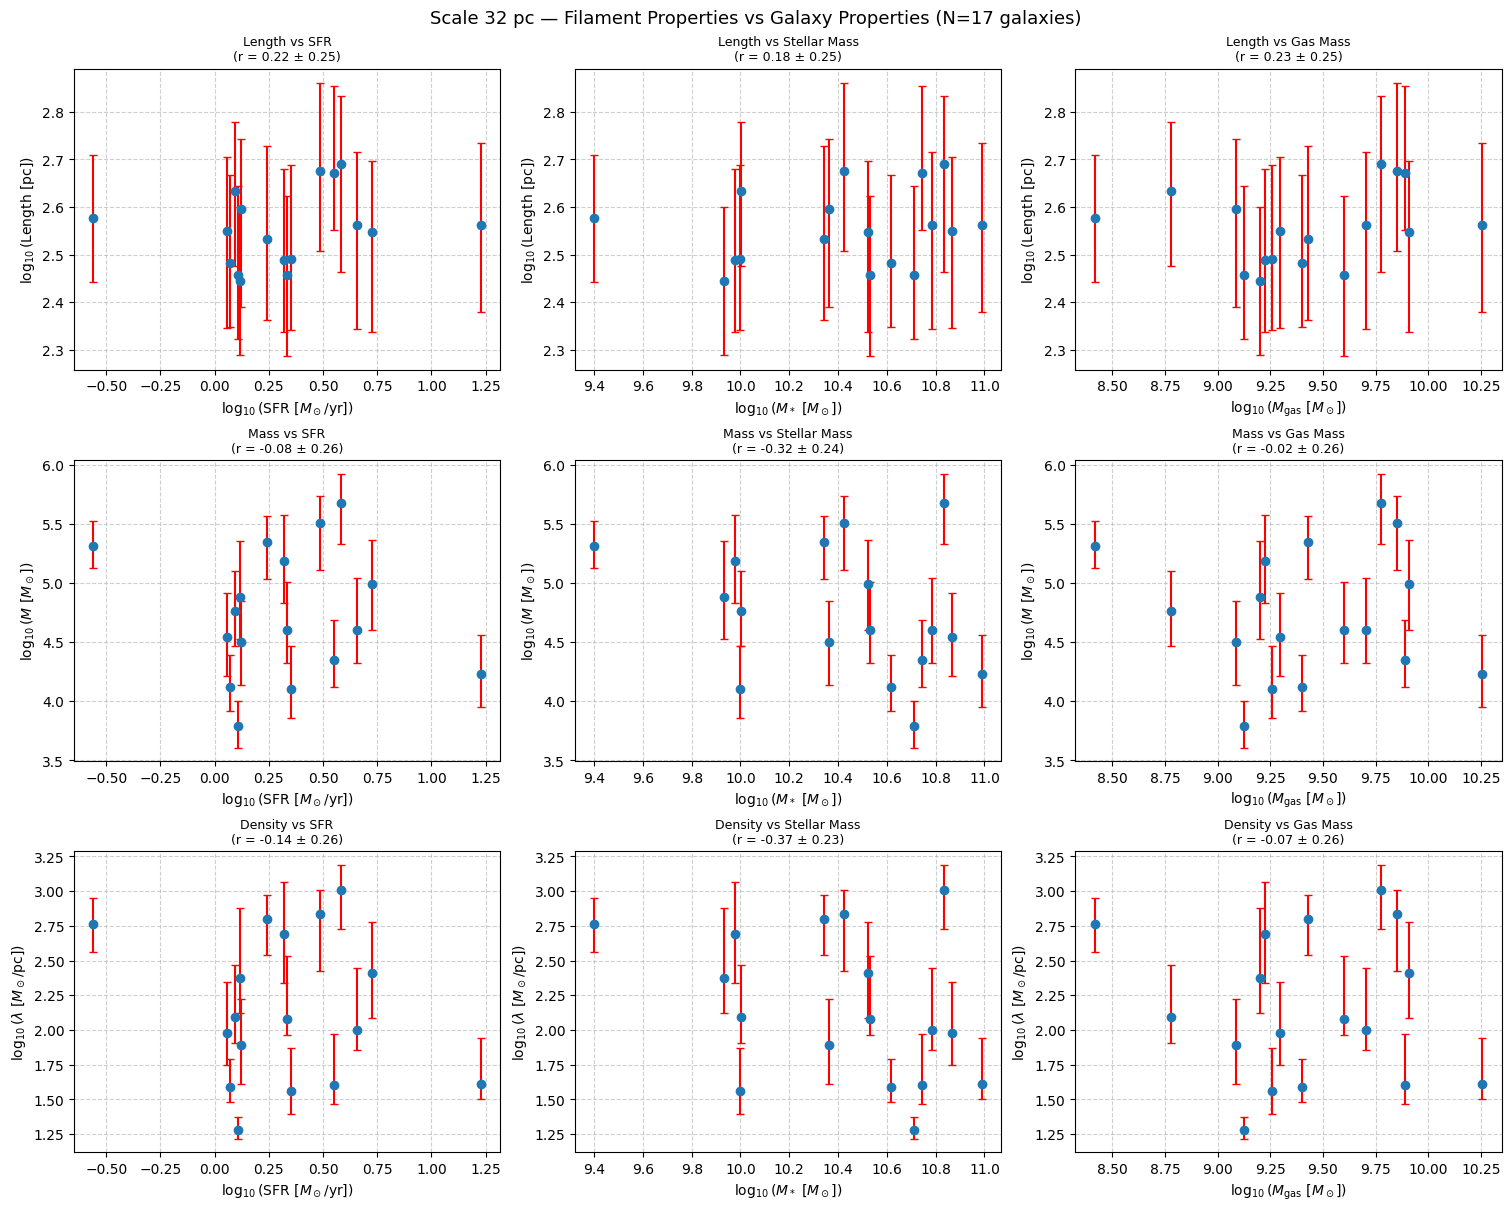

Saved scale 32 → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\scale_32_properties_vs_galaxy.png


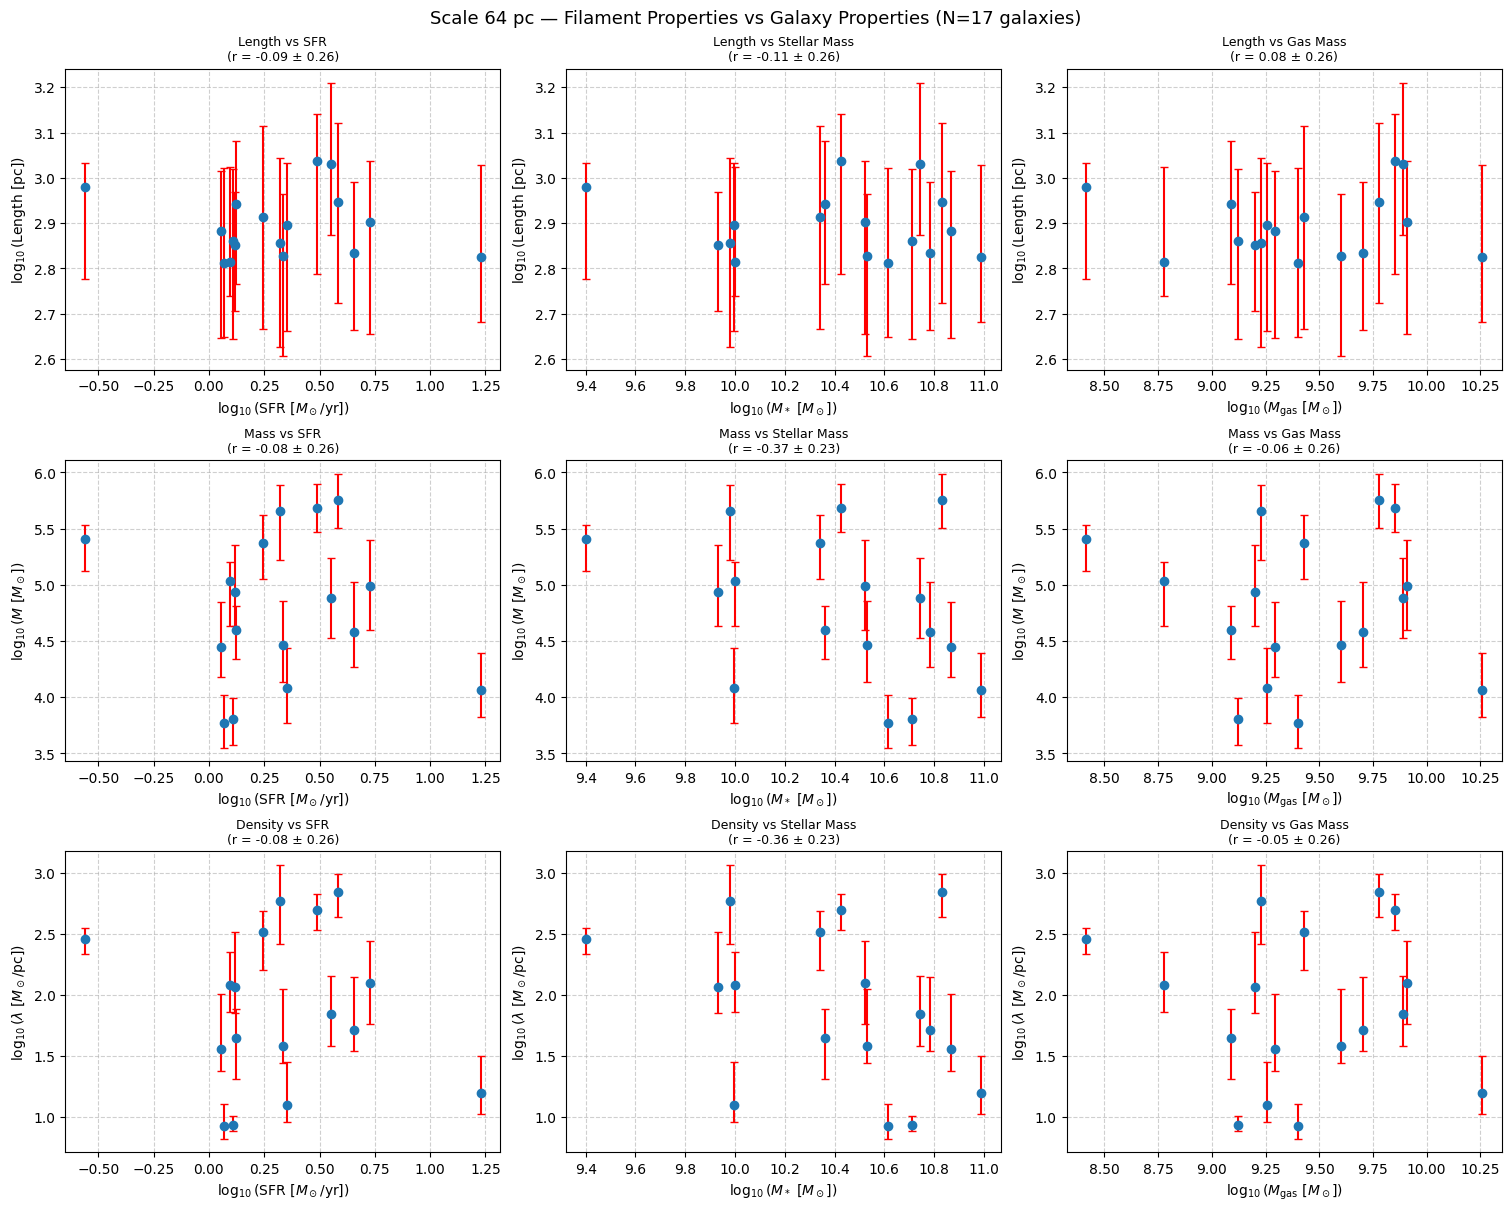

Saved scale 64 → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\scale_64_properties_vs_galaxy.png


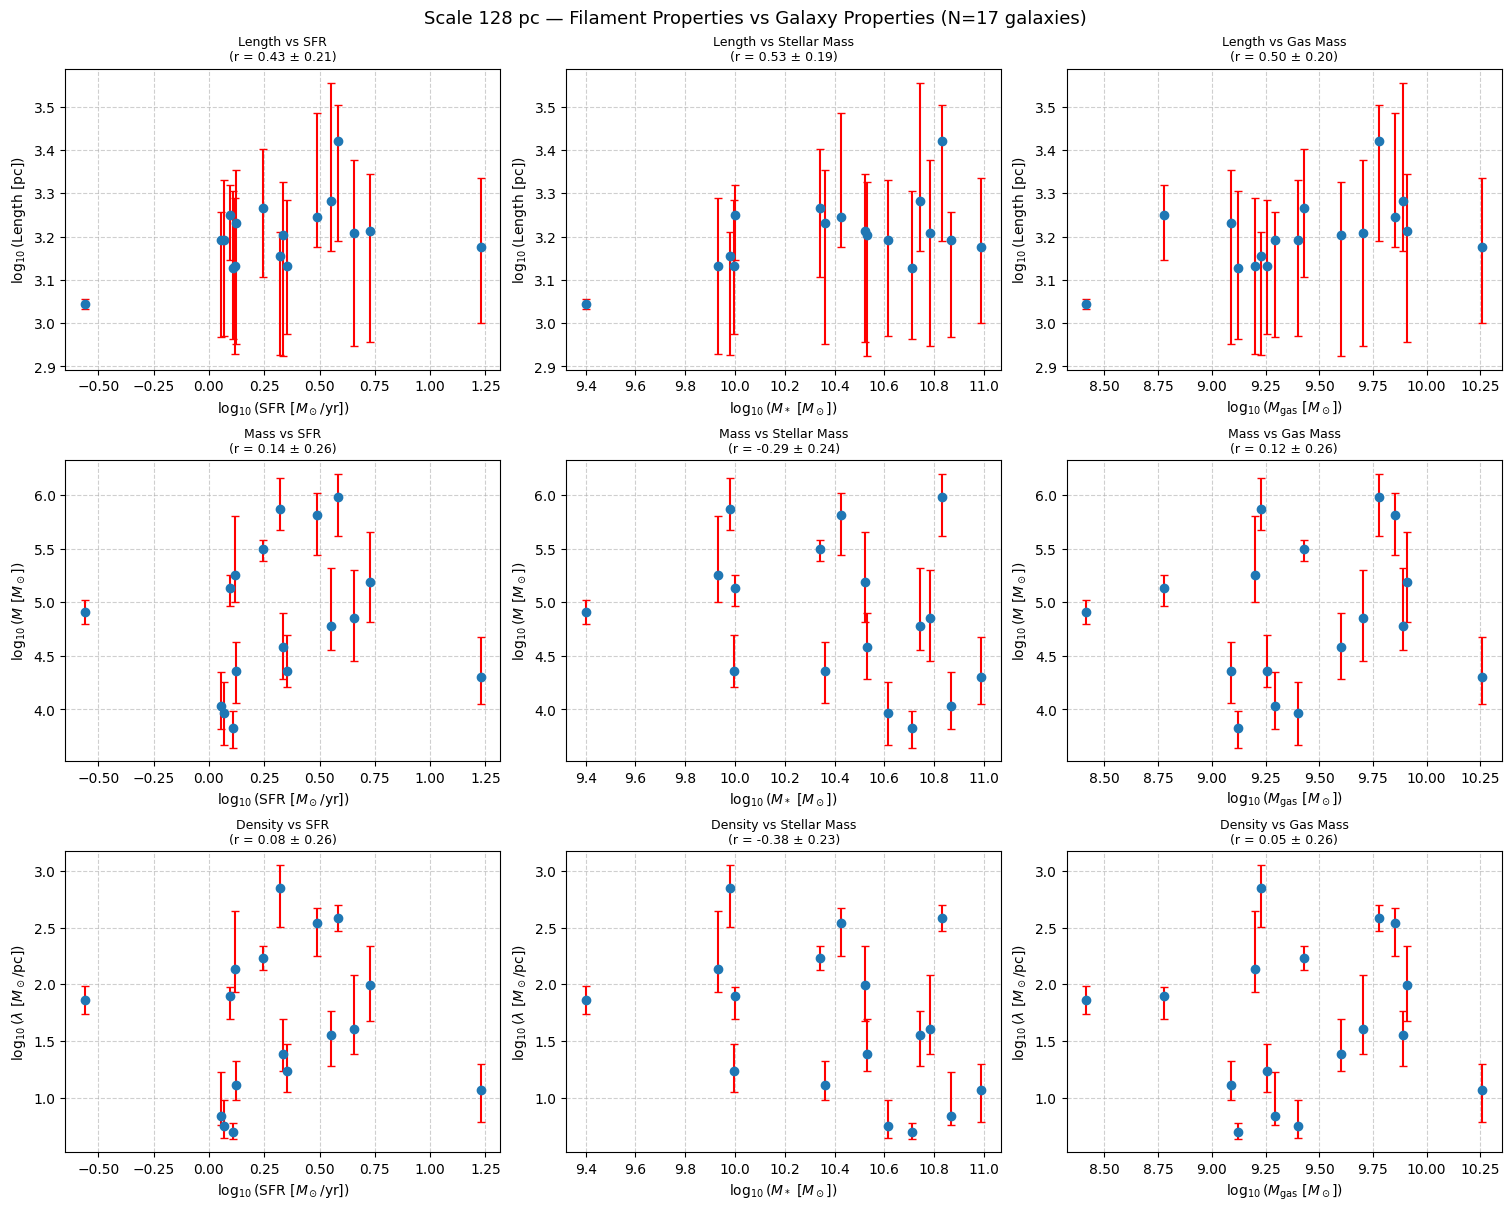

Saved scale 128 → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\scale_128_properties_vs_galaxy.png


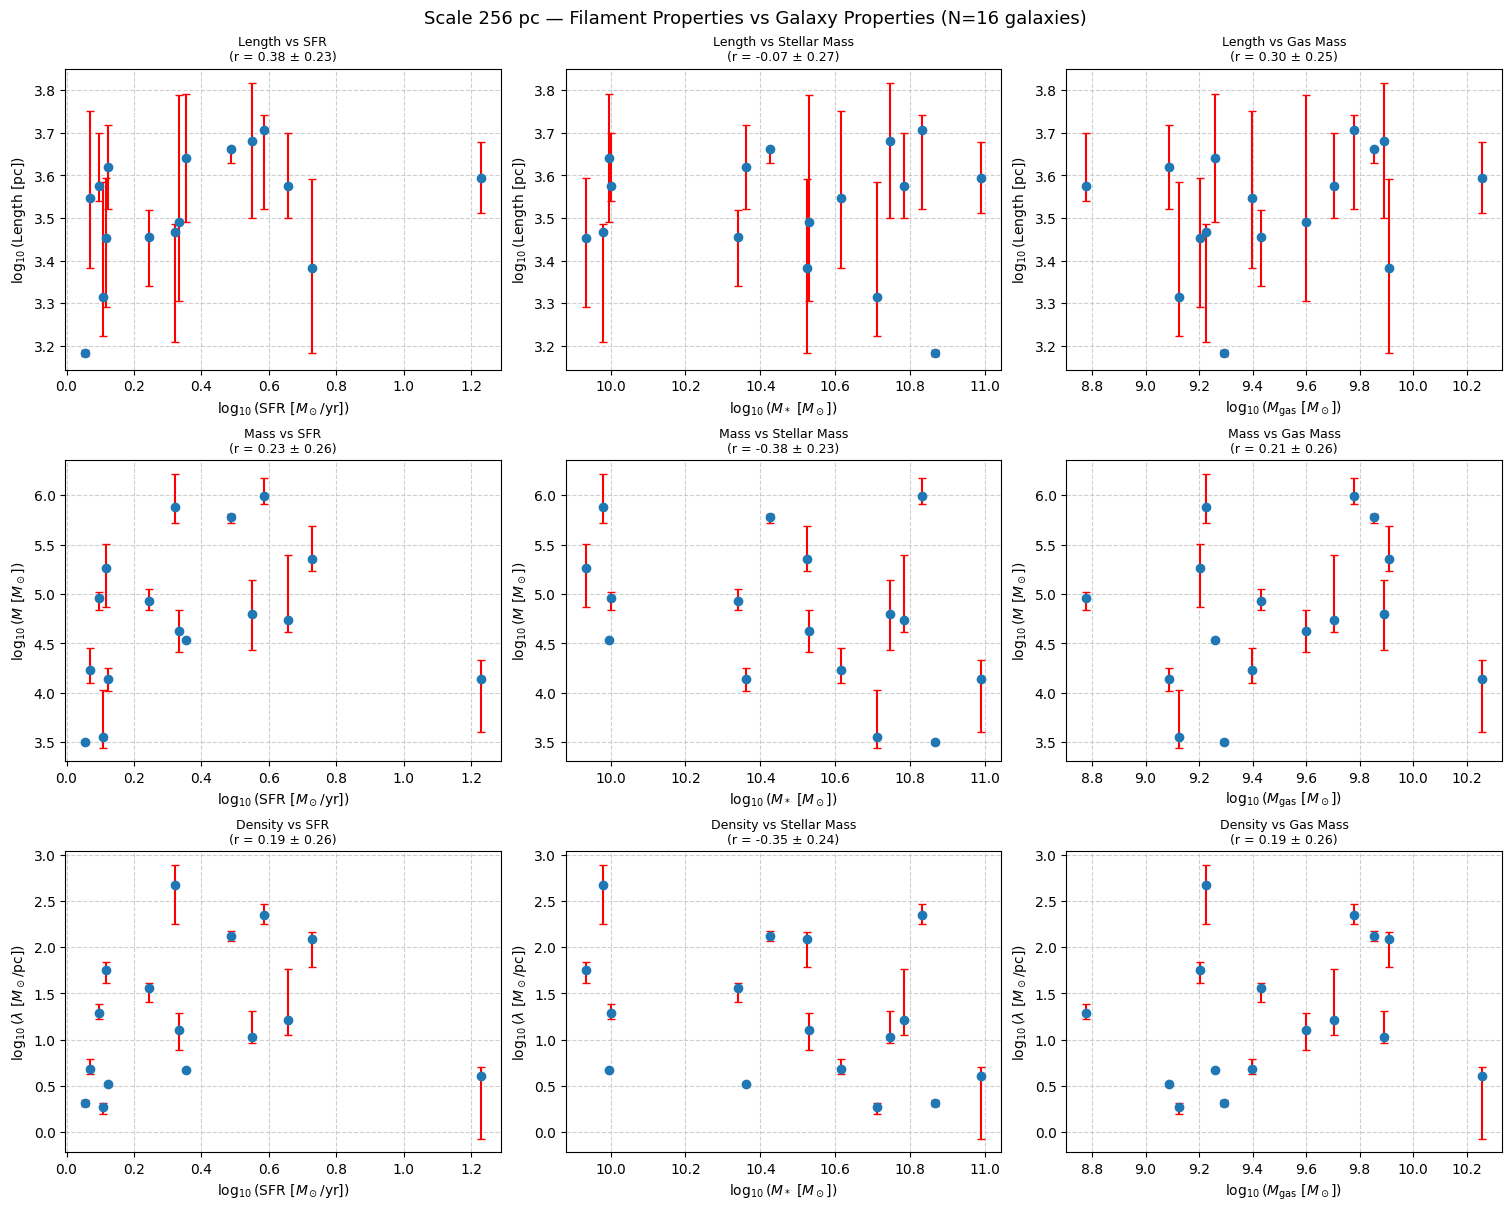

Saved scale 256 → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\scale_256_properties_vs_galaxy.png


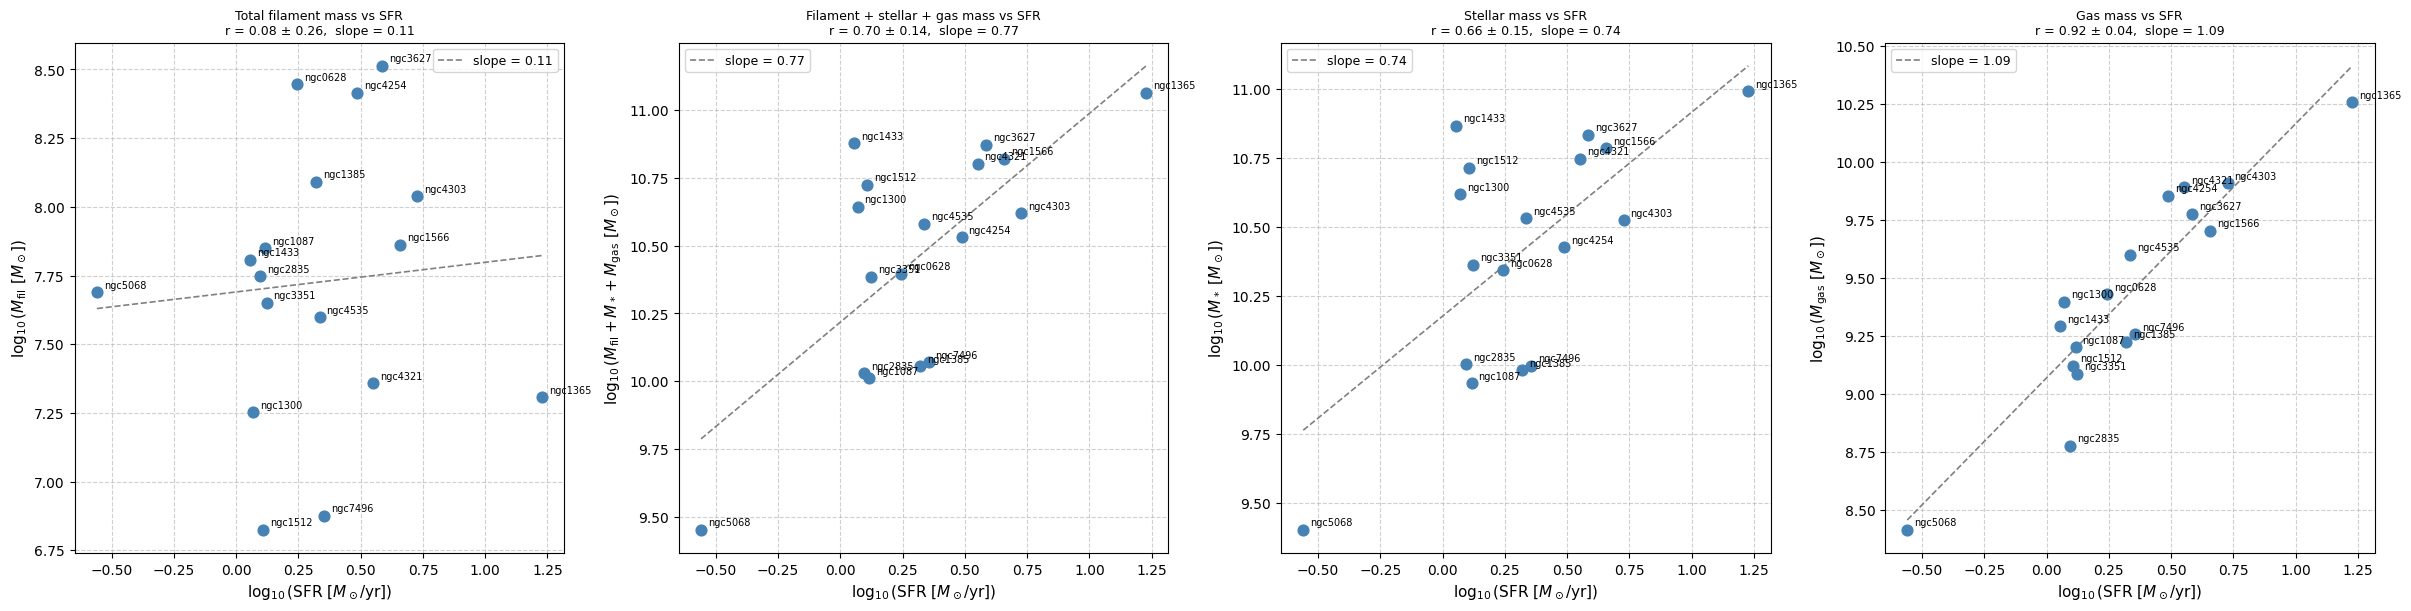

Saved → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\TotalMass_vs_SFR.png


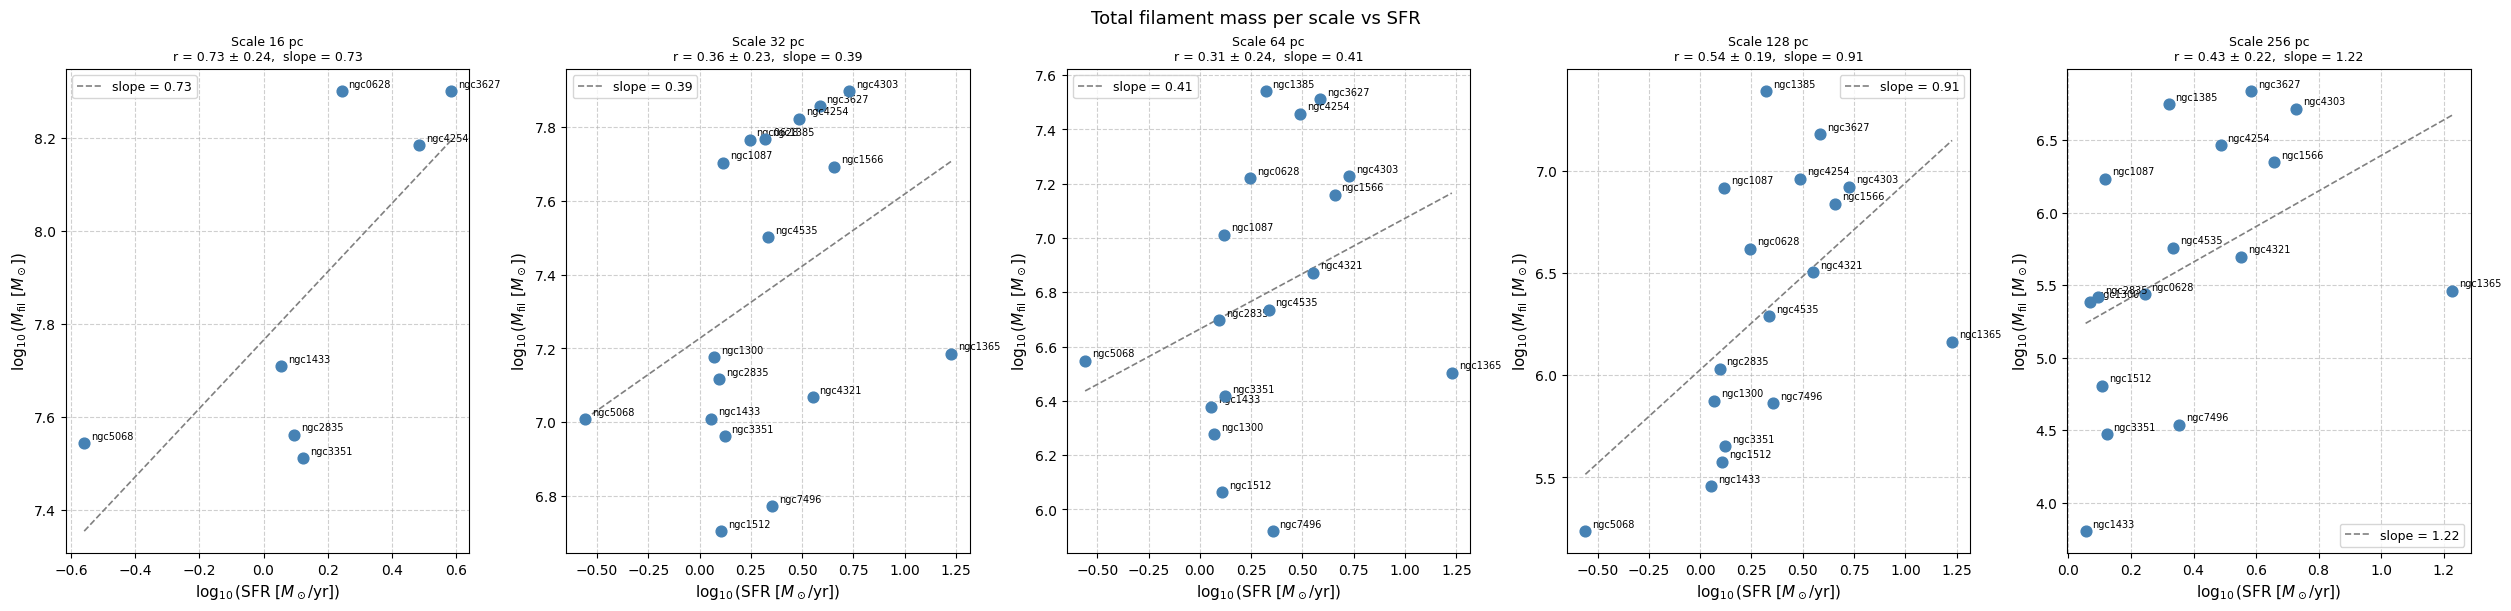

Saved → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\FilamentMass_perScale_vs_SFR.png


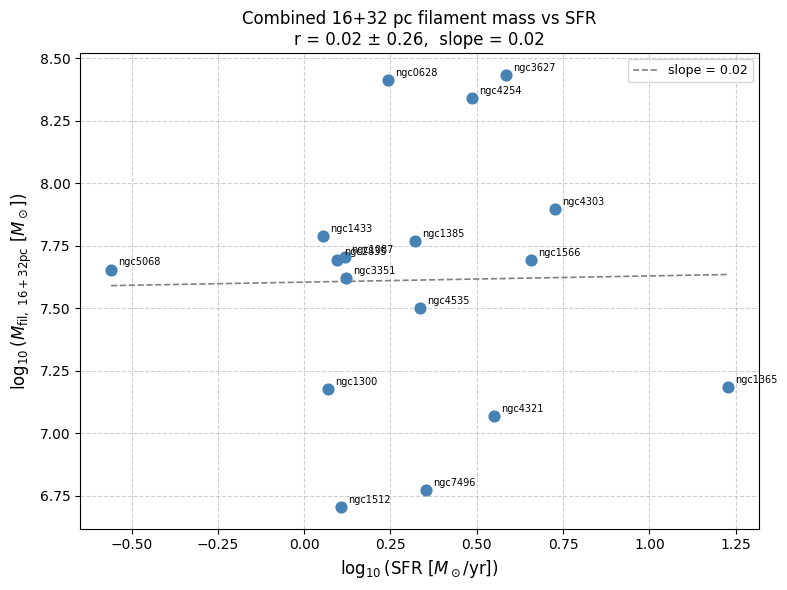

Saved → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\FilamentMass_16+32pc_vs_SFR.png


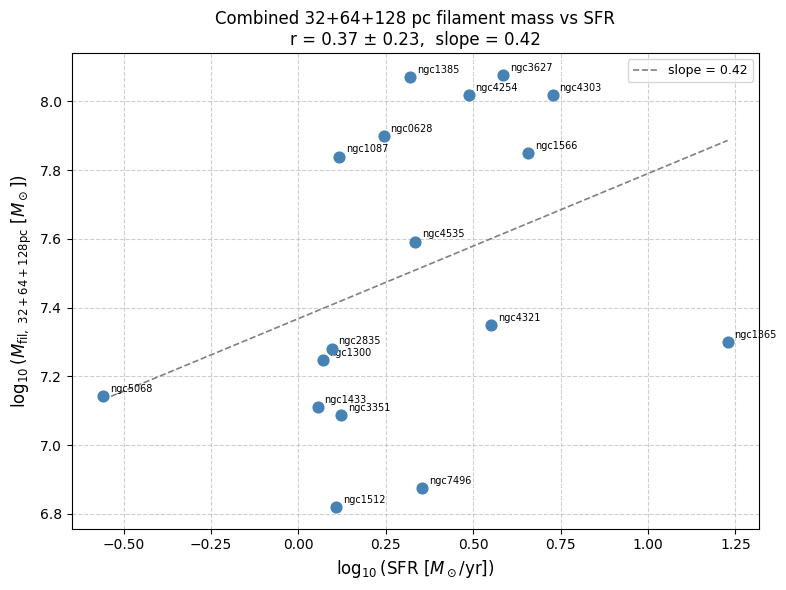

Saved → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\FilamentMass_32+64+128pc_vs_SFR.png
Skipping ngc0628_F770W: has 16 pc data
Skipping ngc1433_F770W: has 16 pc data
Skipping ngc2835_F770W: has 16 pc data
Skipping ngc3351_F770W: has 16 pc data
Skipping ngc3627_F770W: has 16 pc data
Skipping ngc4254_F770W: has 16 pc data
Skipping ngc5068_F770W: has 16 pc data


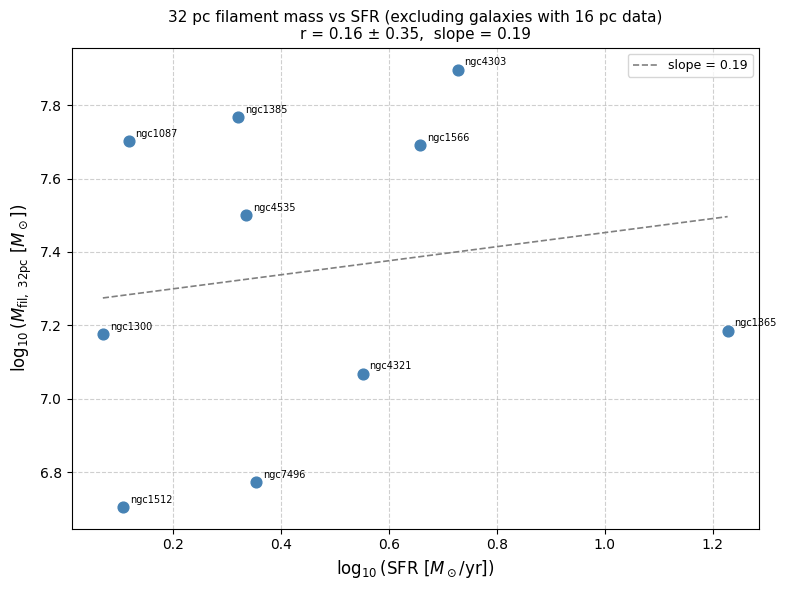

Saved → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\FilamentMass_32pc_no16pc_vs_SFR.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
from scipy.stats import pearsonr

# getProps
def getProps(galaxy_name):
    """Returns (SFR, stellar_mass, gas_mass) in log10 space from PHANGS sample table."""
    base = galaxy_name.split('_')[0]
    path = r"C:\Users\jhoffm72\Downloads\phangs_sample_table_v1p6.fits"
    with fits.open(path) as hdul:
        data = Table(hdul[1].data)
    row = data[data['name'] == base]
    if len(row) == 0:
        raise ValueError(f"Galaxy '{base}' not found in PHANGS sample table")
    SFR          = float(row['props_sfr'][0])
    stellar_mass = float(row['props_mstar'][0])
    gas_mass     = float(row['mh2_phangs'][0])
    # All three are linear — log-transform here
    log_SFR          = np.log10(SFR)          if SFR          > 0 else np.nan
    log_stellar_mass = np.log10(stellar_mass) if stellar_mass > 0 else np.nan
    log_gas_mass     = np.log10(gas_mass)     if gas_mass     > 0 else np.nan
    return log_SFR, log_stellar_mass, log_gas_mass

# corr_with_uncertainty
def corr_with_uncertainty(x, y):
    """Pearson r with 1-sigma uncertainty via Fisher Z transform."""
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    n = len(x)
    if n < 4:
        return np.nan, np.nan
    r, _ = pearsonr(x, y)
    z       = np.arctanh(r)
    sigma_z = 1.0 / np.sqrt(n - 3)
    r_err   = (np.tanh(z + sigma_z) - np.tanh(z - sigma_z)) / 2.0
    return r, r_err

# Helpers
def safe_log(arr):
    """Log10 of positive finite values; everything else becomes NaN."""
    arr = np.array(arr, dtype=np.float64)
    out = np.full_like(arr, np.nan)
    mask = np.isfinite(arr) & (arr > 0)
    out[mask] = np.log10(arr[mask])
    return out

def stats_log(arr):
    """
    Takes a LINEAR array, log-transforms it, then returns
    (log_median, log_p16, log_p84) of finite log values.
    """
    log_arr = safe_log(arr)
    finite  = log_arr[np.isfinite(log_arr)]
    if len(finite) == 0:
        return np.nan, np.nan, np.nan
    return np.median(finite), np.percentile(finite, 16), np.percentile(finite, 84)

# Build master_dict (flat log arrays for KDE) and all_dicts_by_scale
scales     = ['8', '16', '32', '64', '128', '256']
quantities = ["mass", "length", "density", "surface_density", "curvature"]

master_dict        = {q: {scale: [] for scale in scales} for q in quantities}
all_dicts_by_scale = {scale: {} for scale in scales}

for galaxy in valid_galaxies:
    for scale in scales:
        try:
            arr_l = galaxy_data[galaxy]["length"].get(scale)
            arr_m = galaxy_data[galaxy]["mass"].get(scale)
            arr_d = galaxy_data[galaxy]["density"].get(scale)
            arr_c = galaxy_data[galaxy]["curvature"].get(scale)
            arr_s = galaxy_data[galaxy]["surface_density"].get(scale)

            if arr_l is None or len(arr_l) == 0:
                continue

            log_SFR, log_Mstar, log_Mgas = getProps(galaxy)
            if not all(np.isfinite([log_SFR, log_Mstar, log_Mgas])):
                print(f"Skipping {galaxy} at scale {scale}: invalid galaxy props")
                continue

            # Log-transform all filament quantities before storing
            master_dict["length"][scale].append(safe_log(arr_l))
            master_dict["mass"][scale].append(safe_log(arr_m))
            master_dict["density"][scale].append(safe_log(arr_d))
            if arr_c is not None:
                master_dict["curvature"][scale].append(safe_log(arr_c))
            if arr_s is not None:
                master_dict["surface_density"][scale].append(safe_log(arr_s))

            # Per-galaxy stats: log-transform linear arrays, then take percentiles
            l_med, l_lo, l_hi = stats_log(arr_l)
            m_med, m_lo, m_hi = stats_log(arr_m)
            d_med, d_lo, d_hi = stats_log(arr_d)

            all_dicts_by_scale[scale][galaxy] = (
                (l_med, l_lo, l_hi),   # all log10
                (m_med, m_lo, m_hi),   # all log10
                (d_med, d_lo, d_hi),   # all log10
                log_SFR, log_Mstar, log_Mgas
            )

        except Exception as e:
            print(f"Skipping {galaxy} at scale {scale}: {e}")
            continue

# Flatten master_dict lists into single numpy arrays
for quantity in master_dict:
    for scale in master_dict[quantity]:
        if master_dict[quantity][scale]:
            master_dict[quantity][scale] = np.array(
                np.concatenate(master_dict[quantity][scale]), dtype=np.float64
            )
        else:
            master_dict[quantity][scale] = np.array([], dtype=np.float64)

# Labels
y_labels = {
    'Length':  r'$\log_{10}(\mathrm{Length}\ [\mathrm{pc}])$',
    'Mass':    r'$\log_{10}(M\ [M_\odot])$',
    'Density': r'$\log_{10}(\lambda\ [M_\odot/\mathrm{pc}])$',
}
x_labels = {
    'SFR':          r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$',
    'Stellar Mass': r'$\log_{10}(M_*\ [M_\odot])$',
    'Gas Mass':     r'$\log_{10}(M_\mathrm{gas}\ [M_\odot])$',
}

# Per-scale correlation plots
# Values in all_dicts_by_scale are already log10 — errors are symmetric in log space
# err_lo = median - p16,  err_hi = p84 - median  (both positive)
for scale in scales:
    master_dict_scale = all_dicts_by_scale[scale]
    if not master_dict_scale:
        print(f"Scale {scale}: no data, skipping.")
        continue

    rows = list(master_dict_scale.values())

    def unpack(rows, idx):
        meds = np.array([r[idx][0] for r in rows])
        elos = np.array([r[idx][0] - r[idx][1] for r in rows])  # med - p16
        ehis = np.array([r[idx][2] - r[idx][0] for r in rows])  # p84 - med
        return meds, elos, ehis

    l_meds, l_elo, l_ehi = unpack(rows, 0)
    m_meds, m_elo, m_ehi = unpack(rows, 1)
    d_meds, d_elo, d_ehi = unpack(rows, 2)

    y_data_all = {
        'Length':  (l_meds, np.array([l_elo, l_ehi])),
        'Mass':    (m_meds, np.array([m_elo, m_ehi])),
        'Density': (d_meds, np.array([d_elo, d_ehi])),
    }
    x_data_all = {
        'SFR':          np.array([r[3] for r in rows]),
        'Stellar Mass': np.array([r[4] for r in rows]),
        'Gas Mass':     np.array([r[5] for r in rows]),
    }

    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12), constrained_layout=True)

    for i, (y_key, (y_vals, y_err)) in enumerate(y_data_all.items()):
        for j, (x_key, x_vals) in enumerate(x_data_all.items()):
            ax = axes[i, j]
            mask = np.isfinite(x_vals) & np.isfinite(y_vals)
            ax.errorbar(
                x_vals[mask], y_vals[mask],
                yerr=[y_err[0][mask], y_err[1][mask]],
                fmt='o', ecolor='red', capsize=3
            )
            r, r_err = corr_with_uncertainty(x_vals[mask], y_vals[mask])
            corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
            ax.set_xlabel(x_labels[x_key])
            ax.set_ylabel(y_labels[y_key])
            ax.grid(True, which='both', linestyle='--', alpha=0.6)
            ax.set_title(f'{y_key} vs {x_key}\n({corr_str})', fontsize=9)

    n = len(rows)
    plt.suptitle(
        f"Scale {scale} pc — Filament Properties vs Galaxy Properties (N={n} galaxies)",
        fontsize=13
    )
    out = output_folder / f"scale_{scale}_properties_vs_galaxy.png"
    plt.savefig(out, dpi=300, bbox_inches='tight')
    plt.savefig(out.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    print(f"Saved scale {scale} → {out}")

# Total mass vs SFR (four panels)
# All arithmetic done in LINEAR space; log10 applied only at the very end
fig, axes = plt.subplots(1, 4, figsize=(24, 6), constrained_layout=True)

plotted = []  # (log_SFR, log_fil_mass, log_total_mass, log_Mstar, log_Mgas, name)

for galaxy in valid_galaxies:
    try:
        log_SFR, log_Mstar, log_Mgas = getProps(galaxy)
        if not all(np.isfinite([log_SFR, log_Mstar, log_Mgas])):
            continue

        # Sum filament mass in LINEAR space across all scales
        total_fil_mass = 0.0
        for scale in scales:
            arr_m = galaxy_data[galaxy]["mass"].get(scale)
            if arr_m is not None and len(arr_m) > 0:
                # arr_m is linear (confirmed: values up to ~9e5)
                valid = arr_m[np.isfinite(arr_m) & (arr_m > 0)]
                total_fil_mass += float(np.sum(valid))

        if total_fil_mass <= 0:
            continue

        # Convert log10 galaxy props back to linear for addition
        Mstar_lin = 10**log_Mstar   # e.g. ~2e10 M
        Mgas_lin  = 10**log_Mgas    # e.g. ~2.7e9 M

        # Log-transform only after all linear arithmetic is done
        log_fil_mass   = np.log10(total_fil_mass)
        log_total_mass = np.log10(total_fil_mass + Mstar_lin + Mgas_lin)

        plotted.append((
            log_SFR,
            log_fil_mass,
            log_total_mass,
            log_Mstar,   # already log10 from getProps
            log_Mgas,    # already log10 from getProps
            galaxy.replace('_F770W', '')
        ))

    except Exception as e:
        print(f"Skipping {galaxy} for mass vs SFR plot: {e}")
        continue

panel_configs = [
    (
        np.array([p[1] for p in plotted]),
        "Total filament mass vs SFR",
        r'$\log_{10}(M_\mathrm{fil}\ [M_\odot])$',
    ),
    (
        np.array([p[2] for p in plotted]),
        "Filament + stellar + gas mass vs SFR",
        r'$\log_{10}(M_\mathrm{fil} + M_* + M_\mathrm{gas}\ [M_\odot])$',
    ),
    (
        np.array([p[3] for p in plotted]),
        "Stellar mass vs SFR",
        r'$\log_{10}(M_*\ [M_\odot])$',
    ),
    (
        np.array([p[4] for p in plotted]),
        "Gas mass vs SFR",
        r'$\log_{10}(M_\mathrm{gas}\ [M_\odot])$',
    ),
]

px = np.array([p[0] for p in plotted])  # log10 SFR, shared across all panels

for ax, (y_vals, title, ylabel) in zip(axes, panel_configs):
    mask = np.isfinite(px) & np.isfinite(y_vals)

    ax.scatter(px[mask], y_vals[mask], s=60, zorder=3, color='steelblue')

    for p, y in zip(plotted, y_vals):
        if np.isfinite(p[0]) and np.isfinite(y):
            ax.annotate(p[5], (p[0], y),
                        textcoords="offset points", xytext=(5, 3), fontsize=7)

    if mask.sum() >= 3:
        coeffs = np.polyfit(px[mask], y_vals[mask], 1)
        xfit   = np.linspace(px[mask].min(), px[mask].max(), 100)
        ax.plot(xfit, np.polyval(coeffs, xfit),
                color='gray', linestyle='--', linewidth=1.2,
                label=f"slope = {coeffs[0]:.2f}")
        r, r_err = corr_with_uncertainty(px[mask], y_vals[mask])
        corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
        ax.set_title(f"{title}\n{corr_str},  slope = {coeffs[0]:.2f}", fontsize=9)
    else:
        ax.set_title(title, fontsize=9)

    ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=9)

out_mass = output_folder / "TotalMass_vs_SFR.png"
plt.savefig(out_mass, dpi=300, bbox_inches='tight')
plt.savefig(out_mass.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {out_mass}")

# Total filament mass per scale vs SFR
valid_scales = [s for s in scales if s != '8']  # skip 8 if no data
n_scales = len(valid_scales)

fig, axes = plt.subplots(1, n_scales, figsize=(5 * n_scales, 6), constrained_layout=True)
if n_scales == 1:
    axes = [axes]

for ax, scale in zip(axes, valid_scales):
    plotted_x = []
    plotted_y = []

    for galaxy in valid_galaxies:
        try:
            log_SFR, _, _ = getProps(galaxy)
            if not np.isfinite(log_SFR):
                continue

            arr_m = galaxy_data[galaxy]["mass"].get(scale)
            if arr_m is None or len(arr_m) == 0:
                continue

            # Sum in LINEAR space, then log-transform
            valid = arr_m[np.isfinite(arr_m) & (arr_m > 0)]
            if len(valid) == 0:
                continue
            log_mass = np.log10(float(np.sum(valid)))

            ax.scatter(log_SFR, log_mass, s=60, zorder=3, color='steelblue')
            ax.annotate(
                galaxy.replace('_F770W', ''),
                (log_SFR, log_mass),
                textcoords="offset points", xytext=(5, 3), fontsize=7
            )
            plotted_x.append(log_SFR)
            plotted_y.append(log_mass)

        except Exception as e:
            print(f"Skipping {galaxy} at scale {scale}: {e}")
            continue

    if len(plotted_x) >= 3:
        px, py = np.array(plotted_x), np.array(plotted_y)
        mask = np.isfinite(px) & np.isfinite(py)
        coeffs = np.polyfit(px[mask], py[mask], 1)
        xfit   = np.linspace(px[mask].min(), px[mask].max(), 100)
        ax.plot(xfit, np.polyval(coeffs, xfit),
                color='gray', linestyle='--', linewidth=1.2,
                label=f"slope = {coeffs[0]:.2f}")
        r, r_err = corr_with_uncertainty(px[mask], py[mask])
        corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
        ax.set_title(f"Scale {scale} pc\n{corr_str},  slope = {coeffs[0]:.2f}", fontsize=9)
    else:
        ax.set_title(f"Scale {scale} pc", fontsize=9)

    ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$', fontsize=11)
    ax.set_ylabel(r'$\log_{10}(M_\mathrm{fil}\ [M_\odot])$', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=9)

plt.suptitle("Total filament mass per scale vs SFR", fontsize=13)

out_scale = output_folder / "FilamentMass_perScale_vs_SFR.png"
plt.savefig(out_scale, dpi=300, bbox_inches='tight')
plt.savefig(out_scale.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {out_scale}")

# Combined 16+32 pc filament mass vs SFR
fig, ax = plt.subplots(figsize=(8, 6))

plotted_x = []
plotted_y = []

for galaxy in valid_galaxies:
    try:
        log_SFR, _, _ = getProps(galaxy)
        if not np.isfinite(log_SFR):
            continue

        combined_mass = 0.0
        for scale in ['16', '32']:
            arr_m = galaxy_data[galaxy]["mass"].get(scale)
            if arr_m is not None and len(arr_m) > 0:
                valid = arr_m[np.isfinite(arr_m) & (arr_m > 0)]
                combined_mass += float(np.sum(valid))

        if combined_mass <= 0:
            continue

        log_mass = np.log10(combined_mass)

        ax.scatter(log_SFR, log_mass, s=60, zorder=3, color='steelblue')
        ax.annotate(
            galaxy.replace('_F770W', ''),
            (log_SFR, log_mass),
            textcoords="offset points", xytext=(5, 3), fontsize=7
        )
        plotted_x.append(log_SFR)
        plotted_y.append(log_mass)

    except Exception as e:
        print(f"Skipping {galaxy} for 16+32 plot: {e}")
        continue

if len(plotted_x) >= 3:
    px, py = np.array(plotted_x), np.array(plotted_y)
    mask = np.isfinite(px) & np.isfinite(py)
    coeffs = np.polyfit(px[mask], py[mask], 1)
    xfit   = np.linspace(px[mask].min(), px[mask].max(), 100)
    ax.plot(xfit, np.polyval(coeffs, xfit),
            color='gray', linestyle='--', linewidth=1.2,
            label=f"slope = {coeffs[0]:.2f}")
    r, r_err = corr_with_uncertainty(px[mask], py[mask])
    corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
    title_str = f"Combined 16+32 pc filament mass vs SFR\n{corr_str},  slope = {coeffs[0]:.2f}"
else:
    title_str = "Combined 16+32 pc filament mass vs SFR (insufficient data)"

ax.set_title(title_str, fontsize=12)
ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$', fontsize=12)
ax.set_ylabel(r'$\log_{10}(M_\mathrm{fil,\ 16+32pc}\ [M_\odot])$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)
plt.tight_layout()

out_combined = output_folder / "FilamentMass_16+32pc_vs_SFR.png"
plt.savefig(out_combined, dpi=300, bbox_inches='tight')
plt.savefig(out_combined.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {out_combined}")

# Combined 32+64+128 pc filament mass vs SFR
fig, ax = plt.subplots(figsize=(8, 6))

plotted_x = []
plotted_y = []

for galaxy in valid_galaxies:
    try:
        log_SFR, _, _ = getProps(galaxy)
        if not np.isfinite(log_SFR):
            continue

        combined_mass = 0.0
        for scale in ['32', '64', '128']:
            arr_m = galaxy_data[galaxy]["mass"].get(scale)
            if arr_m is not None and len(arr_m) > 0:
                valid = arr_m[np.isfinite(arr_m) & (arr_m > 0)]
                combined_mass += float(np.sum(valid))

        if combined_mass <= 0:
            continue

        log_mass = np.log10(combined_mass)

        ax.scatter(log_SFR, log_mass, s=60, zorder=3, color='steelblue')
        ax.annotate(
            galaxy.replace('_F770W', ''),
            (log_SFR, log_mass),
            textcoords="offset points", xytext=(5, 3), fontsize=7
        )
        plotted_x.append(log_SFR)
        plotted_y.append(log_mass)

    except Exception as e:
        print(f"Skipping {galaxy} for 32+64+128 plot: {e}")
        continue

if len(plotted_x) >= 3:
    px, py = np.array(plotted_x), np.array(plotted_y)
    mask = np.isfinite(px) & np.isfinite(py)
    coeffs = np.polyfit(px[mask], py[mask], 1)
    xfit   = np.linspace(px[mask].min(), px[mask].max(), 100)
    ax.plot(xfit, np.polyval(coeffs, xfit),
            color='gray', linestyle='--', linewidth=1.2,
            label=f"slope = {coeffs[0]:.2f}")
    r, r_err = corr_with_uncertainty(px[mask], py[mask])
    corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
    title_str = f"Combined 32+64+128 pc filament mass vs SFR\n{corr_str},  slope = {coeffs[0]:.2f}"
else:
    title_str = "Combined 32+64+128 pc filament mass vs SFR (insufficient data)"

ax.set_title(title_str, fontsize=12)
ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$', fontsize=12)
ax.set_ylabel(r'$\log_{10}(M_\mathrm{fil,\ 32+64+128pc}\ [M_\odot])$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)
plt.tight_layout()

out_combined = output_folder / "FilamentMass_32+64+128pc_vs_SFR.png"
plt.savefig(out_combined, dpi=300, bbox_inches='tight')
plt.savefig(out_combined.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {out_combined}")

# 32 pc only, excluding galaxies that have 16 pc data
fig, ax = plt.subplots(figsize=(8, 6))

plotted_x = []
plotted_y = []

for galaxy in valid_galaxies:
    try:
        # Skip if this galaxy has any data at 16 pc
        arr_16 = galaxy_data[galaxy]["mass"].get('16')
        has_16pc = arr_16 is not None and len(arr_16[np.isfinite(arr_16) & (arr_16 > 0)]) > 0
        if has_16pc:
            print(f"Skipping {galaxy}: has 16 pc data")
            continue

        log_SFR, _, _ = getProps(galaxy)
        if not np.isfinite(log_SFR):
            continue

        arr_m = galaxy_data[galaxy]["mass"].get('32')
        if arr_m is None or len(arr_m) == 0:
            continue

        valid = arr_m[np.isfinite(arr_m) & (arr_m > 0)]
        if len(valid) == 0:
            continue

        log_mass = np.log10(float(np.sum(valid)))

        ax.scatter(log_SFR, log_mass, s=60, zorder=3, color='steelblue')
        ax.annotate(
            galaxy.replace('_F770W', ''),
            (log_SFR, log_mass),
            textcoords="offset points", xytext=(5, 3), fontsize=7
        )
        plotted_x.append(log_SFR)
        plotted_y.append(log_mass)

    except Exception as e:
        print(f"Skipping {galaxy} for 32pc-no16 plot: {e}")
        continue

if len(plotted_x) >= 3:
    px, py = np.array(plotted_x), np.array(plotted_y)
    mask = np.isfinite(px) & np.isfinite(py)
    coeffs = np.polyfit(px[mask], py[mask], 1)
    xfit   = np.linspace(px[mask].min(), px[mask].max(), 100)
    ax.plot(xfit, np.polyval(coeffs, xfit),
            color='gray', linestyle='--', linewidth=1.2,
            label=f"slope = {coeffs[0]:.2f}")
    r, r_err = corr_with_uncertainty(px[mask], py[mask])
    corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
    title_str = f"32 pc filament mass vs SFR (excluding galaxies with 16 pc data)\n{corr_str},  slope = {coeffs[0]:.2f}"
else:
    title_str = "32 pc filament mass vs SFR — excluding galaxies with 16 pc data\n(insufficient data for fit)"

ax.set_title(title_str, fontsize=11)
ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$', fontsize=12)
ax.set_ylabel(r'$\log_{10}(M_\mathrm{fil,\ 32pc}\ [M_\odot])$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)
plt.tight_layout()

out_32_no16 = output_folder / "FilamentMass_32pc_no16pc_vs_SFR.png"
plt.savefig(out_32_no16, dpi=300, bbox_inches='tight')
plt.savefig(out_32_no16.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {out_32_no16}")



── Sorted min to max (one sum per galaxy) ──
6.3317e+04  |  log10 = 4.802  |  ngc7496_F770W
7.3638e+04  |  log10 = 4.867  |  ngc1512_F770W
1.0170e+05  |  log10 = 5.007  |  ngc1087_F770W
1.0823e+05  |  log10 = 5.034  |  ngc1385_F770W
1.3007e+05  |  log10 = 5.114  |  ngc2835_F770W
1.3815e+05  |  log10 = 5.140  |  ngc4535_F770W
1.9821e+05  |  log10 = 5.297  |  ngc1433_F770W
1.9966e+05  |  log10 = 5.300  |  ngc1300_F770W
2.2305e+05  |  log10 = 5.348  |  ngc4321_F770W
2.3566e+05  |  log10 = 5.372  |  ngc1566_F770W
2.6313e+05  |  log10 = 5.420  |  ngc4303_F770W
2.8177e+05  |  log10 = 5.450  |  ngc3351_F770W
2.8241e+05  |  log10 = 5.451  |  ngc1365_F770W
3.1330e+05  |  log10 = 5.496  |  ngc5068_F770W
4.1936e+05  |  log10 = 5.623  |  ngc4254_F770W
4.2264e+05  |  log10 = 5.626  |  ngc0628_F770W
4.3465e+05  |  log10 = 5.638  |  ngc3627_F770W


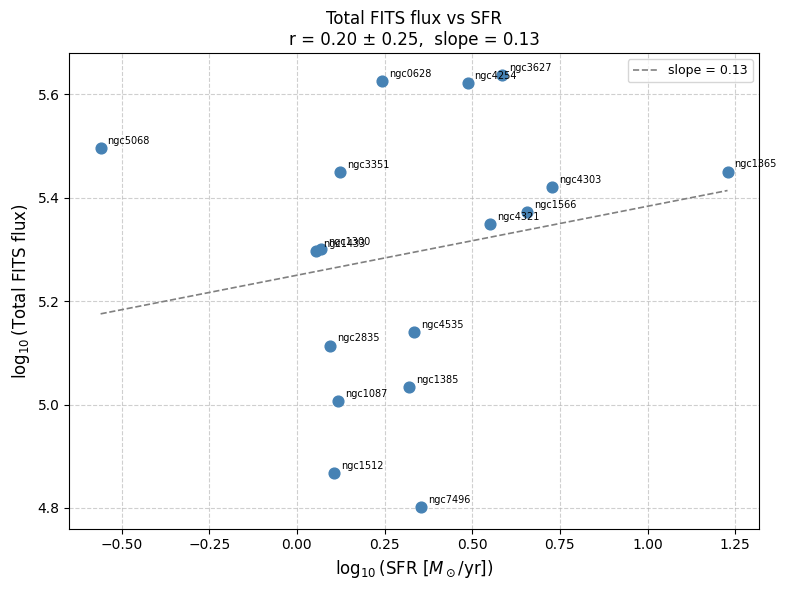

Saved → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\TotalFITSFlux_vs_SFR.png


In [11]:
from astropy.io import fits
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

base_dir = Path(r"C:\Users\jhoffm72\Documents\FilPHANGS\Data")

galaxy_sums = {}  # galaxy -> total sum across all fits files

for galaxy in valid_galaxies:
    synthetic_folder = base_dir / galaxy / "SyntheticMap"
    if not synthetic_folder.exists():
        print(f"{galaxy}: SyntheticMap folder not found")
        continue

    galaxy_total = 0.0
    for fits_file in sorted(synthetic_folder.glob("*.fits")):
        try:
            with fits.open(fits_file) as hdul:
                data = hdul[0].data
                if data is None:
                    continue
                data = np.array(data, dtype=np.float64)
                finite_data = data[np.isfinite(data)]
                galaxy_total += float(np.sum(finite_data))
        except Exception as e:
            print(f"{galaxy}/{fits_file.name}: ERROR — {e}")

    if galaxy_total > 0:
        galaxy_sums[galaxy] = galaxy_total

# Print one line per galaxy, sorted min to max
print("\n── Sorted min to max (one sum per galaxy) ──")
for galaxy, total in sorted(galaxy_sums.items(), key=lambda x: x[1]):
    print(f"{total:.4e}  |  log10 = {np.log10(total):.3f}  |  {galaxy}")

# Plot log(sum) vs log(SFR)
fig, ax = plt.subplots(figsize=(8, 6))

plotted_x = []
plotted_y = []

for galaxy, total in galaxy_sums.items():
    try:
        log_SFR, _, _ = getProps(galaxy)
        if not np.isfinite(log_SFR):
            continue

        log_total = np.log10(total)

        ax.scatter(log_SFR, log_total, s=60, zorder=3, color='steelblue')
        ax.annotate(
            galaxy.replace('_F770W', ''),
            (log_SFR, log_total),
            textcoords="offset points", xytext=(5, 3), fontsize=7
        )
        plotted_x.append(log_SFR)
        plotted_y.append(log_total)

    except Exception as e:
        print(f"Skipping {galaxy} for plot: {e}")
        continue

if len(plotted_x) >= 3:
    px, py = np.array(plotted_x), np.array(plotted_y)
    mask = np.isfinite(px) & np.isfinite(py)
    coeffs = np.polyfit(px[mask], py[mask], 1)
    xfit   = np.linspace(px[mask].min(), px[mask].max(), 100)
    ax.plot(xfit, np.polyval(coeffs, xfit),
            color='gray', linestyle='--', linewidth=1.2,
            label=f"slope = {coeffs[0]:.2f}")
    r, r_err = corr_with_uncertainty(px[mask], py[mask])
    corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
    title_str = f"Total FITS flux vs SFR\n{corr_str},  slope = {coeffs[0]:.2f}"
else:
    title_str = "Total FITS flux vs SFR (insufficient data for fit)"

ax.set_title(title_str, fontsize=12)
ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$', fontsize=12)
ax.set_ylabel(r'$\log_{10}(\mathrm{Total\ FITS\ flux})$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)
plt.tight_layout()

out = output_folder / "TotalFITSFlux_vs_SFR.png"
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.savefig(out.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {out}")


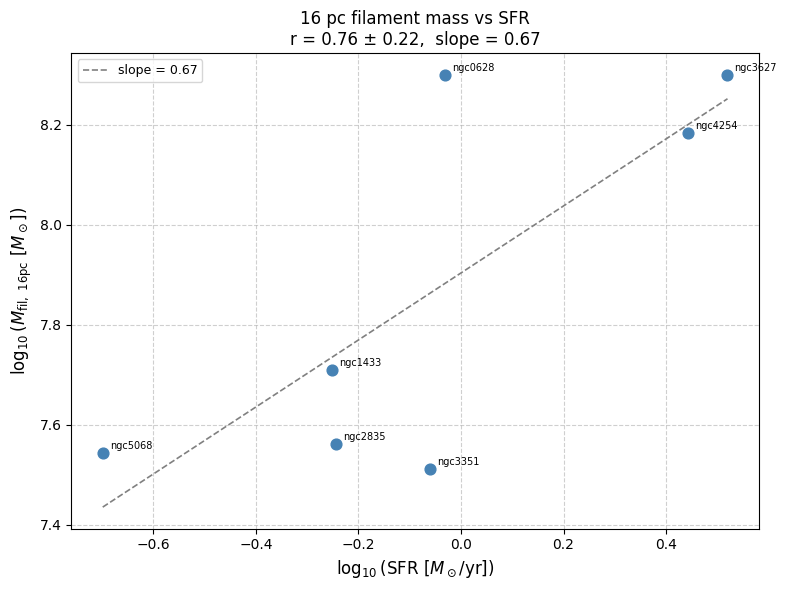

Saved → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\FilamentMass_16pc_vs_SFR.png


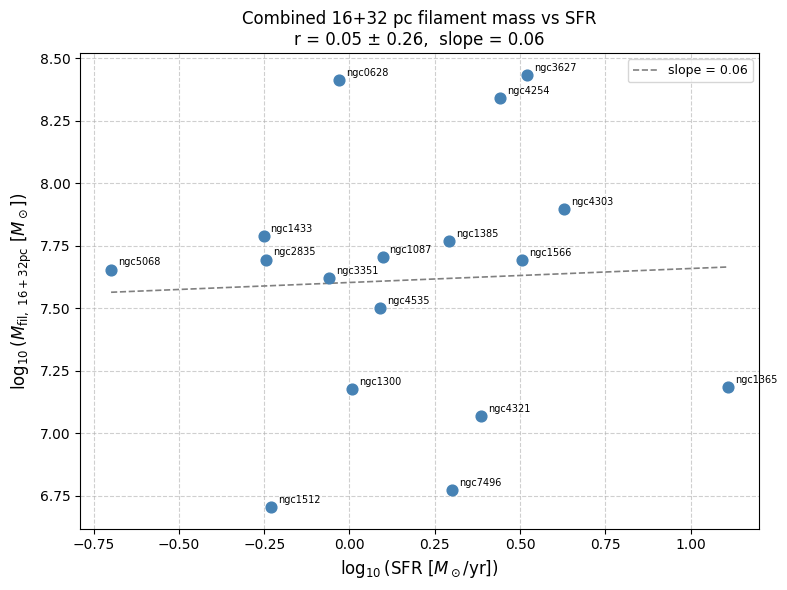

Saved → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\FilamentMass_16+32pc_vs_SFR.png
Skipping ngc0628_F770W: has 16 pc data
Skipping ngc1433_F770W: has 16 pc data
Skipping ngc2835_F770W: has 16 pc data
Skipping ngc3351_F770W: has 16 pc data
Skipping ngc3627_F770W: has 16 pc data
Skipping ngc4254_F770W: has 16 pc data
Skipping ngc5068_F770W: has 16 pc data


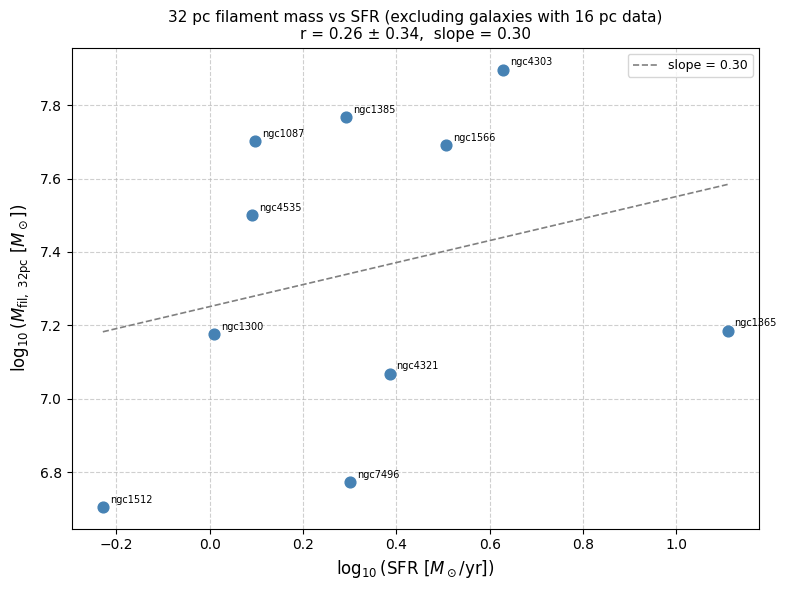

Saved → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\FilamentMass_32pc_no16pc_vs_SFR.png
Skipping ngc1087_F770W: no 16 pc data
Skipping ngc1300_F770W: no 16 pc data
Skipping ngc1365_F770W: no 16 pc data
Skipping ngc1385_F770W: no 16 pc data
Skipping ngc1512_F770W: no 16 pc data
Skipping ngc1566_F770W: no 16 pc data
Skipping ngc4303_F770W: no 16 pc data
Skipping ngc4321_F770W: no 16 pc data
Skipping ngc4535_F770W: no 16 pc data
Skipping ngc7496_F770W: no 16 pc data


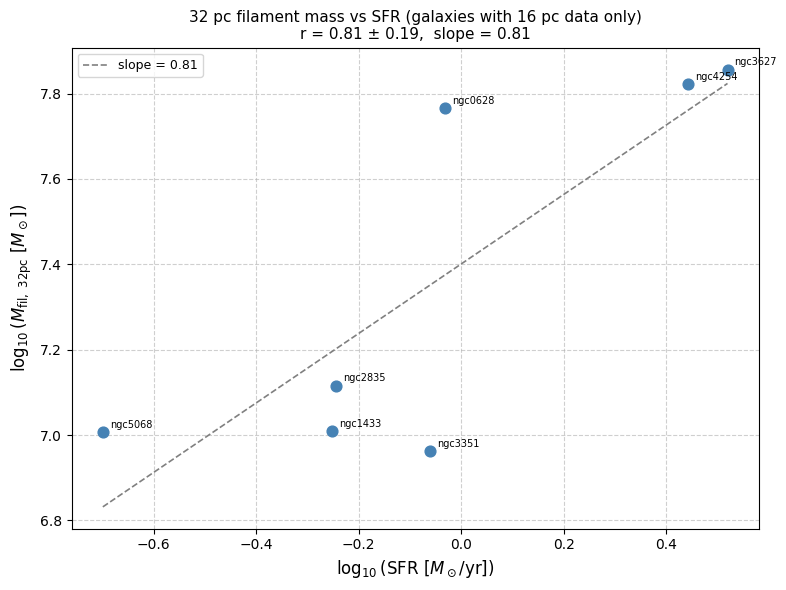

Saved → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\FilamentMass_32pc_with16pc_vs_SFR.png
Skipping ngc1087_F770W: no 16 pc data
Skipping ngc1300_F770W: no 16 pc data
Skipping ngc1365_F770W: no 16 pc data
Skipping ngc1385_F770W: no 16 pc data
Skipping ngc1512_F770W: no 16 pc data
Skipping ngc1566_F770W: no 16 pc data
Skipping ngc4303_F770W: no 16 pc data
Skipping ngc4321_F770W: no 16 pc data
Skipping ngc4535_F770W: no 16 pc data
Skipping ngc7496_F770W: no 16 pc data


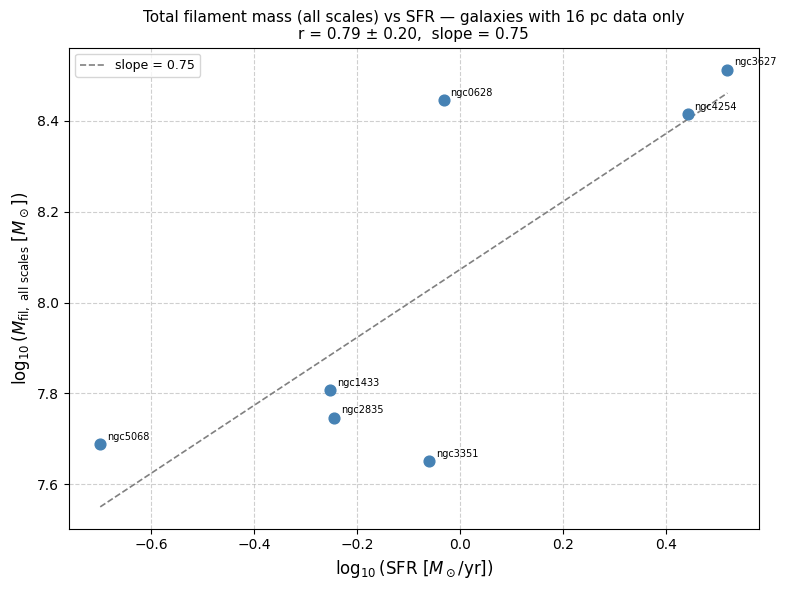

Saved → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\FilamentMass_allScales_with16pc_vs_SFR.png
Skipping ngc0628_F770W: has 16 pc data
Skipping ngc1433_F770W: has 16 pc data
Skipping ngc2835_F770W: has 16 pc data
Skipping ngc3351_F770W: has 16 pc data
Skipping ngc3627_F770W: has 16 pc data
Skipping ngc4254_F770W: has 16 pc data
Skipping ngc5068_F770W: has 16 pc data


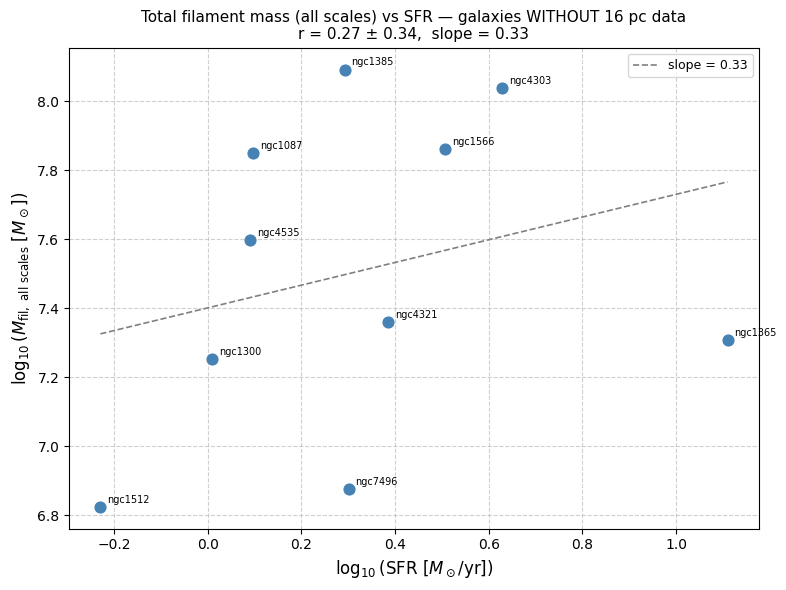

Saved → C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\FilamentMass_allScales_no16pc_vs_SFR.png


In [17]:
# Hardcoded SFR dictionary (Chandar et al. 2025, Table 1)
galaxy_sfr_table1 = {
    "IC 5332":    0.11,
    "ngc0628":  0.93,
    "ngc1087":   1.25,
    "ngc1300":   1.02,
    "ngc1365":  12.88,
    "ngc1385":   1.96,
    "ngc1433":   0.56,
    "ngc1512":   0.59,
    "ngc1566":   3.21,
    "ngc1672":   6.60,
    "ngc2835": 0.57,
    "ngc3351":   0.87,
    "ngc3627":   3.31,
    "ngc4254": 2.77,
    "ngc4303":   4.25,
    "ngc4321":   2.43,
    "ngc4535":   1.23,
    "ngc5068": 0.20,
    "ngc7496":   2.00,
}

def get_sfr(galaxy):
    """
    Returns log10(SFR) for a galaxy.
    Prefers the hardcoded Table 1 values; falls back to getProps with a warning.
    The lookup strips '_F770W' and similar suffixes before checking the dict.
    """
    clean = galaxy.replace('_F770W', '').strip()
    if clean in galaxy_sfr_table1:
        return np.log10(galaxy_sfr_table1[clean])
    else:
        print(f"WARNING: '{clean}' not in hardcoded SFR dict — falling back to getProps()")
        log_SFR, _, _ = getProps(galaxy)
        return log_SFR


# 16 pc filament mass vs SFR
fig, ax = plt.subplots(figsize=(8, 6))
plotted_x, plotted_y = [], []

for galaxy in valid_galaxies:
    try:
        log_SFR = get_sfr(galaxy)
        if not np.isfinite(log_SFR):
            continue

        arr_m = galaxy_data[galaxy]["mass"].get('16')
        if arr_m is None or len(arr_m) == 0:
            continue
        valid = arr_m[np.isfinite(arr_m) & (arr_m > 0)]
        if len(valid) == 0:
            continue

        log_mass = np.log10(float(np.sum(valid)))
        ax.scatter(log_SFR, log_mass, s=60, zorder=3, color='steelblue')
        ax.annotate(galaxy.replace('_F770W', ''), (log_SFR, log_mass),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)
        plotted_x.append(log_SFR)
        plotted_y.append(log_mass)
    except Exception as e:
        print(f"Skipping {galaxy} for 16pc plot: {e}")

if len(plotted_x) >= 3:
    px, py = np.array(plotted_x), np.array(plotted_y)
    mask = np.isfinite(px) & np.isfinite(py)
    coeffs = np.polyfit(px[mask], py[mask], 1)
    xfit = np.linspace(px[mask].min(), px[mask].max(), 100)
    ax.plot(xfit, np.polyval(coeffs, xfit), color='gray', linestyle='--',
            linewidth=1.2, label=f"slope = {coeffs[0]:.2f}")
    r, r_err = corr_with_uncertainty(px[mask], py[mask])
    corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
    title_str = f"16 pc filament mass vs SFR\n{corr_str},  slope = {coeffs[0]:.2f}"
else:
    title_str = "16 pc filament mass vs SFR (insufficient data)"

ax.set_title(title_str, fontsize=12)
ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$', fontsize=12)
ax.set_ylabel(r'$\log_{10}(M_\mathrm{fil,\ 16pc}\ [M_\odot])$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)
plt.tight_layout()

out_16 = output_folder / "FilamentMass_16pc_vs_SFR.png"
plt.savefig(out_16, dpi=300, bbox_inches='tight')
plt.savefig(out_16.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {out_16}")


# Combined 16+32 pc filament mass vs SFR
fig, ax = plt.subplots(figsize=(8, 6))
plotted_x, plotted_y = [], []

for galaxy in valid_galaxies:
    try:
        log_SFR = get_sfr(galaxy)
        if not np.isfinite(log_SFR):
            continue

        combined_mass = 0.0
        for scale in ['16', '32']:
            arr_m = galaxy_data[galaxy]["mass"].get(scale)
            if arr_m is not None and len(arr_m) > 0:
                valid = arr_m[np.isfinite(arr_m) & (arr_m > 0)]
                combined_mass += float(np.sum(valid))

        if combined_mass <= 0:
            continue

        log_mass = np.log10(combined_mass)
        ax.scatter(log_SFR, log_mass, s=60, zorder=3, color='steelblue')
        ax.annotate(galaxy.replace('_F770W', ''), (log_SFR, log_mass),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)
        plotted_x.append(log_SFR)
        plotted_y.append(log_mass)
    except Exception as e:
        print(f"Skipping {galaxy} for 16+32 plot: {e}")

if len(plotted_x) >= 3:
    px, py = np.array(plotted_x), np.array(plotted_y)
    mask = np.isfinite(px) & np.isfinite(py)
    coeffs = np.polyfit(px[mask], py[mask], 1)
    xfit = np.linspace(px[mask].min(), px[mask].max(), 100)
    ax.plot(xfit, np.polyval(coeffs, xfit), color='gray', linestyle='--',
            linewidth=1.2, label=f"slope = {coeffs[0]:.2f}")
    r, r_err = corr_with_uncertainty(px[mask], py[mask])
    corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
    title_str = f"Combined 16+32 pc filament mass vs SFR\n{corr_str},  slope = {coeffs[0]:.2f}"
else:
    title_str = "Combined 16+32 pc filament mass vs SFR (insufficient data)"

ax.set_title(title_str, fontsize=12)
ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$', fontsize=12)
ax.set_ylabel(r'$\log_{10}(M_\mathrm{fil,\ 16+32pc}\ [M_\odot])$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)
plt.tight_layout()

out_combined = output_folder / "FilamentMass_16+32pc_vs_SFR.png"
plt.savefig(out_combined, dpi=300, bbox_inches='tight')
plt.savefig(out_combined.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {out_combined}")


# 32 pc only, excluding galaxies that have 16 pc data
fig, ax = plt.subplots(figsize=(8, 6))
plotted_x, plotted_y = [], []

for galaxy in valid_galaxies:
    try:
        arr_16 = galaxy_data[galaxy]["mass"].get('16')
        has_16pc = arr_16 is not None and len(arr_16[np.isfinite(arr_16) & (arr_16 > 0)]) > 0
        if has_16pc:
            print(f"Skipping {galaxy}: has 16 pc data")
            continue

        log_SFR = get_sfr(galaxy)
        if not np.isfinite(log_SFR):
            continue

        arr_m = galaxy_data[galaxy]["mass"].get('32')
        if arr_m is None or len(arr_m) == 0:
            continue
        valid = arr_m[np.isfinite(arr_m) & (arr_m > 0)]
        if len(valid) == 0:
            continue

        log_mass = np.log10(float(np.sum(valid)))
        ax.scatter(log_SFR, log_mass, s=60, zorder=3, color='steelblue')
        ax.annotate(galaxy.replace('_F770W', ''), (log_SFR, log_mass),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)
        plotted_x.append(log_SFR)
        plotted_y.append(log_mass)
    except Exception as e:
        print(f"Skipping {galaxy} for 32pc-no16 plot: {e}")

if len(plotted_x) >= 3:
    px, py = np.array(plotted_x), np.array(plotted_y)
    mask = np.isfinite(px) & np.isfinite(py)
    coeffs = np.polyfit(px[mask], py[mask], 1)
    xfit = np.linspace(px[mask].min(), px[mask].max(), 100)
    ax.plot(xfit, np.polyval(coeffs, xfit), color='gray', linestyle='--',
            linewidth=1.2, label=f"slope = {coeffs[0]:.2f}")
    r, r_err = corr_with_uncertainty(px[mask], py[mask])
    corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
    title_str = f"32 pc filament mass vs SFR (excluding galaxies with 16 pc data)\n{corr_str},  slope = {coeffs[0]:.2f}"
else:
    title_str = "32 pc filament mass vs SFR — excluding galaxies with 16 pc data\n(insufficient data for fit)"

ax.set_title(title_str, fontsize=11)
ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$', fontsize=12)
ax.set_ylabel(r'$\log_{10}(M_\mathrm{fil,\ 32pc}\ [M_\odot])$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)
plt.tight_layout()

out_32_no16 = output_folder / "FilamentMass_32pc_no16pc_vs_SFR.png"
plt.savefig(out_32_no16, dpi=300, bbox_inches='tight')
plt.savefig(out_32_no16.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {out_32_no16}")

# 32 pc only, restricted to galaxies that HAVE 16 pc data
fig, ax = plt.subplots(figsize=(8, 6))
plotted_x, plotted_y = [], []

for galaxy in valid_galaxies:
    try:
        arr_16 = galaxy_data[galaxy]["mass"].get('16')
        has_16pc = arr_16 is not None and len(arr_16[np.isfinite(arr_16) & (arr_16 > 0)]) > 0
        if not has_16pc:
            print(f"Skipping {galaxy}: no 16 pc data")
            continue

        log_SFR = get_sfr(galaxy)
        if not np.isfinite(log_SFR):
            continue

        arr_m = galaxy_data[galaxy]["mass"].get('32')
        if arr_m is None or len(arr_m) == 0:
            continue
        valid = arr_m[np.isfinite(arr_m) & (arr_m > 0)]
        if len(valid) == 0:
            continue

        log_mass = np.log10(float(np.sum(valid)))
        ax.scatter(log_SFR, log_mass, s=60, zorder=3, color='steelblue')
        ax.annotate(galaxy.replace('_F770W', ''), (log_SFR, log_mass),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)
        plotted_x.append(log_SFR)
        plotted_y.append(log_mass)
    except Exception as e:
        print(f"Skipping {galaxy} for 32pc-with16 plot: {e}")

if len(plotted_x) >= 3:
    px, py = np.array(plotted_x), np.array(plotted_y)
    mask = np.isfinite(px) & np.isfinite(py)
    coeffs = np.polyfit(px[mask], py[mask], 1)
    xfit = np.linspace(px[mask].min(), px[mask].max(), 100)
    ax.plot(xfit, np.polyval(coeffs, xfit), color='gray', linestyle='--',
            linewidth=1.2, label=f"slope = {coeffs[0]:.2f}")
    r, r_err = corr_with_uncertainty(px[mask], py[mask])
    corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
    title_str = f"32 pc filament mass vs SFR (galaxies with 16 pc data only)\n{corr_str},  slope = {coeffs[0]:.2f}"
else:
    title_str = "32 pc filament mass vs SFR — galaxies with 16 pc data only\n(insufficient data for fit)"

ax.set_title(title_str, fontsize=11)
ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$', fontsize=12)
ax.set_ylabel(r'$\log_{10}(M_\mathrm{fil,\ 32pc}\ [M_\odot])$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)
plt.tight_layout()

out_32_with16 = output_folder / "FilamentMass_32pc_with16pc_vs_SFR.png"
plt.savefig(out_32_with16, dpi=300, bbox_inches='tight')
plt.savefig(out_32_with16.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {out_32_with16}")

# Total filament mass (all scales) vs SFR — restricted to galaxies with 16 pc data
fig, ax = plt.subplots(figsize=(8, 6))
plotted_x, plotted_y = [], []

for galaxy in valid_galaxies:
    try:
        # Only include galaxies that have 16 pc filament data
        arr_16 = galaxy_data[galaxy]["mass"].get('16')
        has_16pc = arr_16 is not None and len(arr_16[np.isfinite(arr_16) & (arr_16 > 0)]) > 0
        if not has_16pc:
            print(f"Skipping {galaxy}: no 16 pc data")
            continue

        log_SFR = get_sfr(galaxy)
        if not np.isfinite(log_SFR):
            continue

        # Sum filament mass in LINEAR space across ALL scales
        total_fil_mass = 0.0
        for scale in scales:
            arr_m = galaxy_data[galaxy]["mass"].get(scale)
            if arr_m is not None and len(arr_m) > 0:
                valid = arr_m[np.isfinite(arr_m) & (arr_m > 0)]
                total_fil_mass += float(np.sum(valid))

        if total_fil_mass <= 0:
            continue

        log_mass = np.log10(total_fil_mass)
        ax.scatter(log_SFR, log_mass, s=60, zorder=3, color='steelblue')
        ax.annotate(galaxy.replace('_F770W', ''), (log_SFR, log_mass),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)
        plotted_x.append(log_SFR)
        plotted_y.append(log_mass)
    except Exception as e:
        print(f"Skipping {galaxy} for total-mass-with16 plot: {e}")

if len(plotted_x) >= 3:
    px, py = np.array(plotted_x), np.array(plotted_y)
    mask = np.isfinite(px) & np.isfinite(py)
    coeffs = np.polyfit(px[mask], py[mask], 1)
    xfit = np.linspace(px[mask].min(), px[mask].max(), 100)
    ax.plot(xfit, np.polyval(coeffs, xfit), color='gray', linestyle='--',
            linewidth=1.2, label=f"slope = {coeffs[0]:.2f}")
    r, r_err = corr_with_uncertainty(px[mask], py[mask])
    corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
    title_str = f"Total filament mass (all scales) vs SFR — galaxies with 16 pc data only\n{corr_str},  slope = {coeffs[0]:.2f}"
else:
    title_str = "Total filament mass (all scales) vs SFR — galaxies with 16 pc data only\n(insufficient data for fit)"

ax.set_title(title_str, fontsize=11)
ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$', fontsize=12)
ax.set_ylabel(r'$\log_{10}(M_\mathrm{fil,\ all\ scales}\ [M_\odot])$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)
plt.tight_layout()

out_total_with16 = output_folder / "FilamentMass_allScales_with16pc_vs_SFR.png"
plt.savefig(out_total_with16, dpi=300, bbox_inches='tight')
plt.savefig(out_total_with16.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {out_total_with16}")

# Total filament mass (all scales) vs SFR — galaxies WITHOUT 16 pc data
fig, ax = plt.subplots(figsize=(8, 6))
plotted_x, plotted_y = [], []

for galaxy in valid_galaxies:
    try:
        # Only include galaxies that have NO 16 pc filament data
        arr_16 = galaxy_data[galaxy]["mass"].get('16')
        has_16pc = arr_16 is not None and len(arr_16[np.isfinite(arr_16) & (arr_16 > 0)]) > 0
        if has_16pc:
            print(f"Skipping {galaxy}: has 16 pc data")
            continue

        log_SFR = get_sfr(galaxy)
        if not np.isfinite(log_SFR):
            continue

        # Sum filament mass in LINEAR space across ALL scales
        total_fil_mass = 0.0
        for scale in scales:
            arr_m = galaxy_data[galaxy]["mass"].get(scale)
            if arr_m is not None and len(arr_m) > 0:
                valid = arr_m[np.isfinite(arr_m) & (arr_m > 0)]
                total_fil_mass += float(np.sum(valid))

        if total_fil_mass <= 0:
            continue

        log_mass = np.log10(total_fil_mass)
        ax.scatter(log_SFR, log_mass, s=60, zorder=3, color='steelblue')
        ax.annotate(galaxy.replace('_F770W', ''), (log_SFR, log_mass),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)
        plotted_x.append(log_SFR)
        plotted_y.append(log_mass)
    except Exception as e:
        print(f"Skipping {galaxy} for total-mass-no16 plot: {e}")

if len(plotted_x) >= 3:
    px, py = np.array(plotted_x), np.array(plotted_y)
    mask = np.isfinite(px) & np.isfinite(py)
    coeffs = np.polyfit(px[mask], py[mask], 1)
    xfit = np.linspace(px[mask].min(), px[mask].max(), 100)
    ax.plot(xfit, np.polyval(coeffs, xfit), color='gray', linestyle='--',
            linewidth=1.2, label=f"slope = {coeffs[0]:.2f}")
    r, r_err = corr_with_uncertainty(px[mask], py[mask])
    corr_str = f"r = {r:.2f} ± {r_err:.2f}" if not np.isnan(r) else "r = N/A"
    title_str = f"Total filament mass (all scales) vs SFR — galaxies WITHOUT 16 pc data\n{corr_str},  slope = {coeffs[0]:.2f}"
else:
    title_str = "Total filament mass (all scales) vs SFR — galaxies WITHOUT 16 pc data\n(insufficient data for fit)"

ax.set_title(title_str, fontsize=11)
ax.set_xlabel(r'$\log_{10}(\mathrm{SFR}\ [M_\odot/\mathrm{yr}])$', fontsize=12)
ax.set_ylabel(r'$\log_{10}(M_\mathrm{fil,\ all\ scales}\ [M_\odot])$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)
plt.tight_layout()

out_total_no16 = output_folder / "FilamentMass_allScales_no16pc_vs_SFR.png"
plt.savefig(out_total_no16, dpi=300, bbox_inches='tight')
plt.savefig(out_total_no16.with_suffix('.pdf'), format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved → {out_total_no16}")
